# Model Results Analysis

In [1]:
import pandas as pd
import requests
import pvlib
import matplotlib.pyplot as plt  # for visualization
import math
from datetime import datetime
#from ast import literal_eval
import numpy as np
from statistics import median
from statistics import mean
from pprint import pprint
import seaborn as sns

In [2]:
#variables - MAKE SURE THESE ARE IDENTICAL TO WHAT WAS USED IN THE MODEL
#myNetworks = ['bowling green','long island city','sunnyside','crown heights','grasslands','fresh kills','williamsburg','northeast bronx','ridgewood']
myNetworks = ['bowling green','long island city','sunnyside','grasslands','fresh kills','northeast bronx']


In [3]:
f = '1783744348'
directory = ''
networkFile = f'network_df_{f}'
resultsFile = f'results_df_{f}'

# Read Data

In [4]:
network_df = pd.read_csv(f'results/{directory}{networkFile}.csv')
#network_df = network_df.drop(columns='Unnamed: 0')
network_df.head()

,network,load1W,load2W,load1RW,l1_annValResProgram_csrp,l1_annValResProgram_dlrp,l1_annValResTot,l1_annValPer_csrp,l1_annValPer_dlrp,l1_annValPer,l1_annTotVal,l2_annValResProgram_csrp,l2_annValResProgram_dlrp,l2_annValResTot,l2_annValPer_csrp,l2_annValPer_dlrp,l2_annValPer,l2_annTotVal
0,bowling green,1000,100,75,90.0,90.0,180.0,4.0,1.0,5.0,185.0,9.0,9.0,18.0,0.4,0.1,0.5,18.5
1,long island city,1000,100,75,90.0,90.0,180.0,4.0,1.0,5.0,185.0,9.0,9.0,18.0,0.4,0.1,0.5,18.5
2,sunnyside,1000,100,75,90.0,90.0,180.0,4.0,1.0,5.0,185.0,9.0,9.0,18.0,0.4,0.1,0.5,18.5
3,grasslands,1000,100,75,30.0,90.0,120.0,4.0,1.0,5.0,125.0,3.0,9.0,12.0,0.4,0.1,0.5,12.5
4,fresh kills,1000,100,75,30.0,90.0,120.0,4.0,1.0,5.0,125.0,3.0,9.0,12.0,0.4,0.1,0.5,12.5


## Read Model Results

In [29]:
results_df = pd.read_csv(f'results/{directory}/{resultsFile}.csv')

#drop the index if it was saved in the  file
#results_df = results_df.drop(columns='Unnamed: 0')
results_df.head()

,network,eventStart,dlrp_rate,csrp_rate,az,pvW,microinverter,batModel,batWh,batWhAC,...,gridValue_load1R,load1_NPV,load2_NPV,load1R_NPV,load1_PBP,load2_PBP,load1R_PBP,load1_LCOSS,load2_LCOSS,load1R_LCOSS
0,bowling green,11,18,18,180,0,True,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...",{'without_surplus': np.float64(-948.8396694043...,{'without_surplus': np.float64(-948.9336776434...,{'without_surplus': np.float64(-173.6856279018...,{'without_surplus': np.float64(-92.60062732478...,{'without_surplus': np.float64(-92.48527647711...,{'without_surplus': np.float64(10.017200583540...,{'without_surplus': np.float64(0.0144007678806...,{'without_surplus': np.float64(108.49883798574...,{'without_surplus': np.float64(0.3305836651843...
1,bowling green,11,18,18,180,50,True,Explorer 300 Plus,288.0,195.84,...,{'avg_hourly_surpluskWAC_byMonth': [0.01065215...,{'without_surplus': np.float64(-1010.225557544...,{'without_surplus': np.float64(-849.9839106710...,{'without_surplus': np.float64(174.38259931723...,{'without_surplus': np.float64(-157.6954954051...,{'without_surplus': np.float64(69.103591707257...,{'without_surplus': np.float64(6.7954669844444...,{'without_surplus': np.float64(0.0154020213218...,{'without_surplus': np.float64(2.1558559020722...,{'without_surplus': np.float64(0.3271785034234...
2,bowling green,11,18,18,180,100,True,Explorer 300 Plus,288.0,195.84,...,{'avg_hourly_surpluskWAC_byMonth': [0.02130430...,{'without_surplus': np.float64(-1032.416445684...,{'without_surplus': np.float64(-711.8391436986...,{'without_surplus': np.float64(432.54493651980...,{'without_surplus': np.float64(-365.7095784109...,{'without_surplus': np.float64(27.111599134344...,{'without_surplus': np.float64(5.6187787299365...,{'without_surplus': np.float64(0.0158453587031...,{'without_surplus': np.float64(1.1092148358535...,{'without_surplus': np.float64(0.3132269944316...
3,bowling green,11,18,18,180,0,False,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...",{'without_surplus': np.float64(-732.5792465738...,{'without_surplus': np.float64(-732.5792465738...,{'without_surplus': np.float64(42.574794928584...,{'without_surplus': np.float64(-19.50136799735...,{'without_surplus': np.float64(-19.50136799735...,{'without_surplus': np.float64(7.4268503967568...,{'without_surplus': np.float64(0.0113224374040...,{'without_surplus': np.float64(85.298032042592...,{'without_surplus': np.float64(0.2599175882052...
4,bowling green,11,18,18,180,50,False,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...",{'without_surplus': np.float64(-621.3846373228...,{'without_surplus': np.float64(-621.3656447351...,{'without_surplus': np.float64(446.54151553682...,{'without_surplus': np.float64(-345.6905611597...,{'without_surplus': np.float64(-346.1524508302...,{'without_surplus': np.float64(4.6299153970150...,{'without_surplus': np.float64(0.0098235427024...,{'without_surplus': np.float64(74.102977260150...,{'without_surplus': np.float64(0.2255731453259...


In [30]:
results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,6780.000000,6780.000000,6780.000000,6780.0,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.0
mean,14.500000,19.166667,14.000000,180.0,413.097345,1535.517451,1051.378062,0.859646,307.103490,1498.860119,3718.584071,10.187902,9.325979,0.0
std,1.802909,2.608938,5.657271,0.0,327.830184,689.853381,468.107122,0.037394,137.970676,564.196526,716.181628,1.962141,0.805681,0.0
min,11.000000,18.000000,6.000000,180.0,0.000000,204.000000,146.880000,0.800000,40.800000,162.223750,2500.000000,6.849315,6.849315,0.0
25%,14.000000,18.000000,6.000000,180.0,150.000000,1024.000000,696.320000,0.850000,204.800000,1087.105988,3000.000000,8.219178,8.219178,0.0
50%,15.000000,18.000000,18.000000,180.0,350.000000,1536.000000,1105.920000,0.850000,307.200000,1496.209244,3500.000000,9.589041,9.589041,0.0
75%,16.000000,18.000000,18.000000,180.0,650.000000,2048.000000,1392.640000,0.900000,409.600000,1898.224737,4000.000000,10.958904,10.000000,0.0
max,16.000000,25.000000,18.000000,180.0,1200.000000,3072.000000,2088.960000,0.900000,614.400000,3004.950000,6000.000000,16.438356,10.000000,0.0


In [31]:
results_df.columns

Index(['network', 'eventStart', 'dlrp_rate', 'csrp_rate', 'az', 'pvW',
       'microinverter', 'batModel', 'batWh', 'batWhAC', 'effEff',
       'dischargeRateW', 'capex', 'cycles', 'lifespan', 'workingLife',
       'dailyPVWhAC_4M', 'annualPVkWhDC_degraded', 'annualPVkWhAC_degraded',
       'immediateEventAmt', 'csrpMaxFlex', 'csrpLoad1_flex', 'csrpLoad2_flex',
       'csrpLoad1replacement_flex', 'csrpLoad1_percentage',
       'csrpLoad2_percentage', 'csrpLoad1replacement_percentage',
       'csrpLoad1Income', 'csrpLoad2Income', 'csrpLoad1RIncome', 'dlrpMaxFlex',
       'dlrpLoad1_flex', 'dlrpLoad2_flex', 'dlrpLoad1replacement_flex',
       'dlrpLoad1_percentage', 'dlrpLoad2_percentage',
       'dlrpLoad1replacement_percentage', 'dlrpLoad1Income', 'dlrpLoad2Income',
       'dlrpLoad1RIncome', 'annDRIncomeLoad1', 'annDRIncomeLoad2',
       'annDRIncomeLoad1R', 'gridValue_load1', 'gridValue_load2',
       'gridValue_load1R', 'load1_NPV', 'load2_NPV', 'load1R_NPV', 'load1_PBP',
       'lo

In [32]:
#these are the columns with lists in them
strToList = ['dailyPVWhAC_4M','annualPVkWhDC_degraded','annualPVkWhAC_degraded','csrpMaxFlex',
             'csrpLoad1_percentage','csrpLoad2_percentage', 'csrpLoad1replacement_percentage',
             'csrpLoad1Income', 'csrpLoad2Income', 'csrpLoad1RIncome','dlrpMaxFlex',
             'csrpLoad1_flex','csrpLoad2_flex','csrpLoad1replacement_flex',
             'dlrpLoad1_flex','dlrpLoad2_flex','dlrpLoad1replacement_flex',
             'dlrpLoad1_percentage', 'dlrpLoad2_percentage', 'dlrpLoad1replacement_percentage',
             'dlrpLoad1Income','dlrpLoad2Income', 'dlrpLoad1RIncome', 'annDRIncomeLoad1',
             'annDRIncomeLoad2', 'annDRIncomeLoad1R']

#these are the columns with dictionaries in them
strToDict =[ 'gridValue_load1','gridValue_load2','gridValue_load1R',
             'load1_NPV', 'load2_NPV','load1R_NPV',
             'load1_PBP', 'load2_PBP', 'load1R_PBP',
             'load1_LCOSS','load2_LCOSS','load1R_LCOSS']

# for c in strToList:
#     print(c)
#     print(results_df[c].iloc[0]) 
#     print('')

In [33]:
safe_env = {"np": np, "nan": np.nan}
for c in strToList:
    results_df[c] = results_df[c].apply(lambda x: eval(str(x),safe_env))


In [34]:
for c in strToDict:
    results_df[c] = results_df[c].apply(lambda x: eval(str(x),safe_env))

In [35]:
results_df.head()

,network,eventStart,dlrp_rate,csrp_rate,az,pvW,microinverter,batModel,batWh,batWhAC,...,gridValue_load1R,load1_NPV,load2_NPV,load1R_NPV,load1_PBP,load2_PBP,load1R_PBP,load1_LCOSS,load2_LCOSS,load1R_LCOSS
0,bowling green,11,18,18,180,0,True,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...","{'without_surplus': -948.8396694043083, 'with_...","{'without_surplus': -948.9336776434645, 'with_...","{'without_surplus': -173.68562790183734, 'with...","{'without_surplus': -92.60062732478417, 'with_...","{'without_surplus': -92.48527647711114, 'with_...","{'without_surplus': 10.017200583540074, 'with_...","{'without_surplus': 0.01440076788063322, 'with...","{'without_surplus': 108.498837985749, 'with_su...","{'without_surplus': 0.33058366518434756, 'with..."
1,bowling green,11,18,18,180,50,True,Explorer 300 Plus,288.0,195.84,...,{'avg_hourly_surpluskWAC_byMonth': [0.01065215...,"{'without_surplus': -1010.2255575441623, 'with...","{'without_surplus': -849.9839106710682, 'with_...","{'without_surplus': 174.38259931723925, 'with_...","{'without_surplus': -157.69549540519967, 'with...","{'without_surplus': 69.10359170725779, 'with_s...","{'without_surplus': 6.7954669844444195, 'with_...","{'without_surplus': 0.015402021321879907, 'wit...","{'without_surplus': 2.1558559020722172, 'with_...","{'without_surplus': 0.32717850342342114, 'with..."
2,bowling green,11,18,18,180,100,True,Explorer 300 Plus,288.0,195.84,...,{'avg_hourly_surpluskWAC_byMonth': [0.02130430...,"{'without_surplus': -1032.4164456840158, 'with...","{'without_surplus': -711.8391436986716, 'with_...","{'without_surplus': 432.54493651980704, 'with_...","{'without_surplus': -365.7095784109886, 'with_...","{'without_surplus': 27.111599134344235, 'with_...","{'without_surplus': 5.618778729936595, 'with_s...","{'without_surplus': 0.015845358703164655, 'wit...","{'without_surplus': 1.1092148358535494, 'with_...","{'without_surplus': 0.31322699443163016, 'with..."
3,bowling green,11,18,18,180,0,False,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...","{'without_surplus': -732.5792465738864, 'with_...","{'without_surplus': -732.5792465738864, 'with_...","{'without_surplus': 42.574794928584545, 'with_...","{'without_surplus': -19.501367997355796, 'with...","{'without_surplus': -19.501367997355796, 'with...","{'without_surplus': 7.426850396756814, 'with_s...","{'without_surplus': 0.01132243740400989, 'with...","{'without_surplus': 85.2980320425926, 'with_su...","{'without_surplus': 0.2599175882052585, 'with_..."
4,bowling green,11,18,18,180,50,False,Explorer 300 Plus,288.0,195.84,...,"{'avg_hourly_surpluskWAC_byMonth': [0.0, 0.0, ...","{'without_surplus': -621.3846373228645, 'with_...","{'without_surplus': -621.3656447351076, 'with_...","{'without_surplus': 446.5415155368257, 'with_s...","{'without_surplus': -345.6905611597875, 'with_...","{'without_surplus': -346.15245083024837, 'with...","{'without_surplus': 4.629915397015077, 'with_s...","{'without_surplus': 0.009823542702495318, 'wit...","{'without_surplus': 74.1029772601508, 'with_su...","{'without_surplus': 0.2255731453259463, 'with_..."


In [36]:
# #check data types if needed
# for k in list(results_df.keys()):
#     #print(k)
#     #print(type(results_df.iloc[0][k]))
#     if type(results_df.iloc[0][k]).__name__ == 'str':
#         print('str: ' + k)
#         print(type(results_df.iloc[0][k][0]))
#     if type(results_df.iloc[0][k]).__name__ in  ['int','float','numpy.int64','numpy.float64'] :
#         print('number: ' + k)
#         print(type(results_df.iloc[0][k]))
#     elif type(results_df.iloc[0][k]).__name__ == 'list':
#         print('list')
#         print(type(results_df.iloc[0][k][0]))
#     elif type(results_df.iloc[0][k]).__name__ == 'dict':
#         print('dict')
#         print(type(results_df.iloc[0][k]))
#     #print(results_df.iloc[0][k])

In [37]:
results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC,effEff,dischargeRateW,capex,cycles,lifespan,workingLife,immediateEventAmt
count,6780.000000,6780.000000,6780.000000,6780.0,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.000000,6780.0
mean,14.500000,19.166667,14.000000,180.0,413.097345,1535.517451,1051.378062,0.859646,307.103490,1498.860119,3718.584071,10.187902,9.325979,0.0
std,1.802909,2.608938,5.657271,0.0,327.830184,689.853381,468.107122,0.037394,137.970676,564.196526,716.181628,1.962141,0.805681,0.0
min,11.000000,18.000000,6.000000,180.0,0.000000,204.000000,146.880000,0.800000,40.800000,162.223750,2500.000000,6.849315,6.849315,0.0
25%,14.000000,18.000000,6.000000,180.0,150.000000,1024.000000,696.320000,0.850000,204.800000,1087.105988,3000.000000,8.219178,8.219178,0.0
50%,15.000000,18.000000,18.000000,180.0,350.000000,1536.000000,1105.920000,0.850000,307.200000,1496.209244,3500.000000,9.589041,9.589041,0.0
75%,16.000000,18.000000,18.000000,180.0,650.000000,2048.000000,1392.640000,0.900000,409.600000,1898.224737,4000.000000,10.958904,10.000000,0.0
max,16.000000,25.000000,18.000000,180.0,1200.000000,3072.000000,2088.960000,0.900000,614.400000,3004.950000,6000.000000,16.438356,10.000000,0.0


## Read in network data

In [38]:
# read in network data to dataframe
networks_df = pd.read_csv('data/conEdNetworks2025.csv')

display(networks_df.head())

,borough,network,start time,end time,tier
0,bronx,central bronx,16:00,20:00,2
1,bronx,fordham,16:00,20:00,2
2,bronx,northeast bronx,16:00,20:00,2
3,bronx,riverdale,16:00,20:00,1
4,bronx,southeast bronx,16:00,20:00,1


In [39]:
#returns the network info for a given network
#args: network name
def getNetworkInfo(networkName):
    return networks_df.loc[networks_df['network']== networkName]

#returns the tier for a given item in the network info list
#args: network name
def getDLRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['tier'].iloc[0]
    #tier 2 networks pay at a higher rate
    if t == 1:
        return 18
    else:
        return 25
    
#returns the borough for a given item in the network info list
#args: network name
def getCSRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['borough'].iloc[0]
    #westchester and staten island pay at a lower rate
    if t not in ['westchester','staten island']:
        return 18
    else:
        return 6

#args: network name
def getTotalRate(networkName):
    return getDLRPrate(networkName) + getCSRPrate(networkName)
    
#returns borough name
#args: network name
def getBorough(networkName):
    n = getNetworkInfo(networkName)
    return n['borough'].iloc[0]

#returns event start time
#args: network name
def getStartTime(networkName):
    n = getNetworkInfo(networkName)
    return int(n['start time'].iloc[0].split(":")[0])

# Analyze Results

In [40]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6780 entries, 0 to 6779
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   network                          6780 non-null   object 
 1   eventStart                       6780 non-null   int64  
 2   dlrp_rate                        6780 non-null   int64  
 3   csrp_rate                        6780 non-null   int64  
 4   az                               6780 non-null   int64  
 5   pvW                              6780 non-null   int64  
 6   microinverter                    6780 non-null   bool   
 7   batModel                         6780 non-null   object 
 8   batWh                            6780 non-null   float64
 9   batWhAC                          6780 non-null   float64
 10  effEff                           6780 non-null   float64
 11  dischargeRateW                   6780 non-null   float64
 12  capex               

In [41]:
# all results
analyze_df = results_df[['network','pvW','microinverter','batModel', 'batWh', 'batWhAC','capex',
                         'workingLife','csrpLoad1_flex','csrpLoad2_flex','csrpLoad1replacement_flex','dlrpLoad1_flex','dlrpLoad2_flex','dlrpLoad1replacement_flex',#'csrpMaxFlex','dlrpMaxFlex',
                         'csrpLoad1_percentage', 'csrpLoad2_percentage','csrpLoad1replacement_percentage',
                         'dlrpLoad1_percentage', 'dlrpLoad2_percentage','dlrpLoad1replacement_percentage',
                         'gridValue_load1','gridValue_load2','gridValue_load1R',
                         'load1_NPV', 'load2_NPV','load1R_NPV',
                         'load1_PBP', 'load2_PBP', 'load1R_PBP',
                         'load1_LCOSS','load2_LCOSS','load1R_LCOSS']]

# results with plug-in solar
analyze_plugin_df = analyze_df[analyze_df['microinverter']== True]

# results without plug-in solar
analyze_offgrid_df = analyze_df[analyze_df['microinverter']== False]

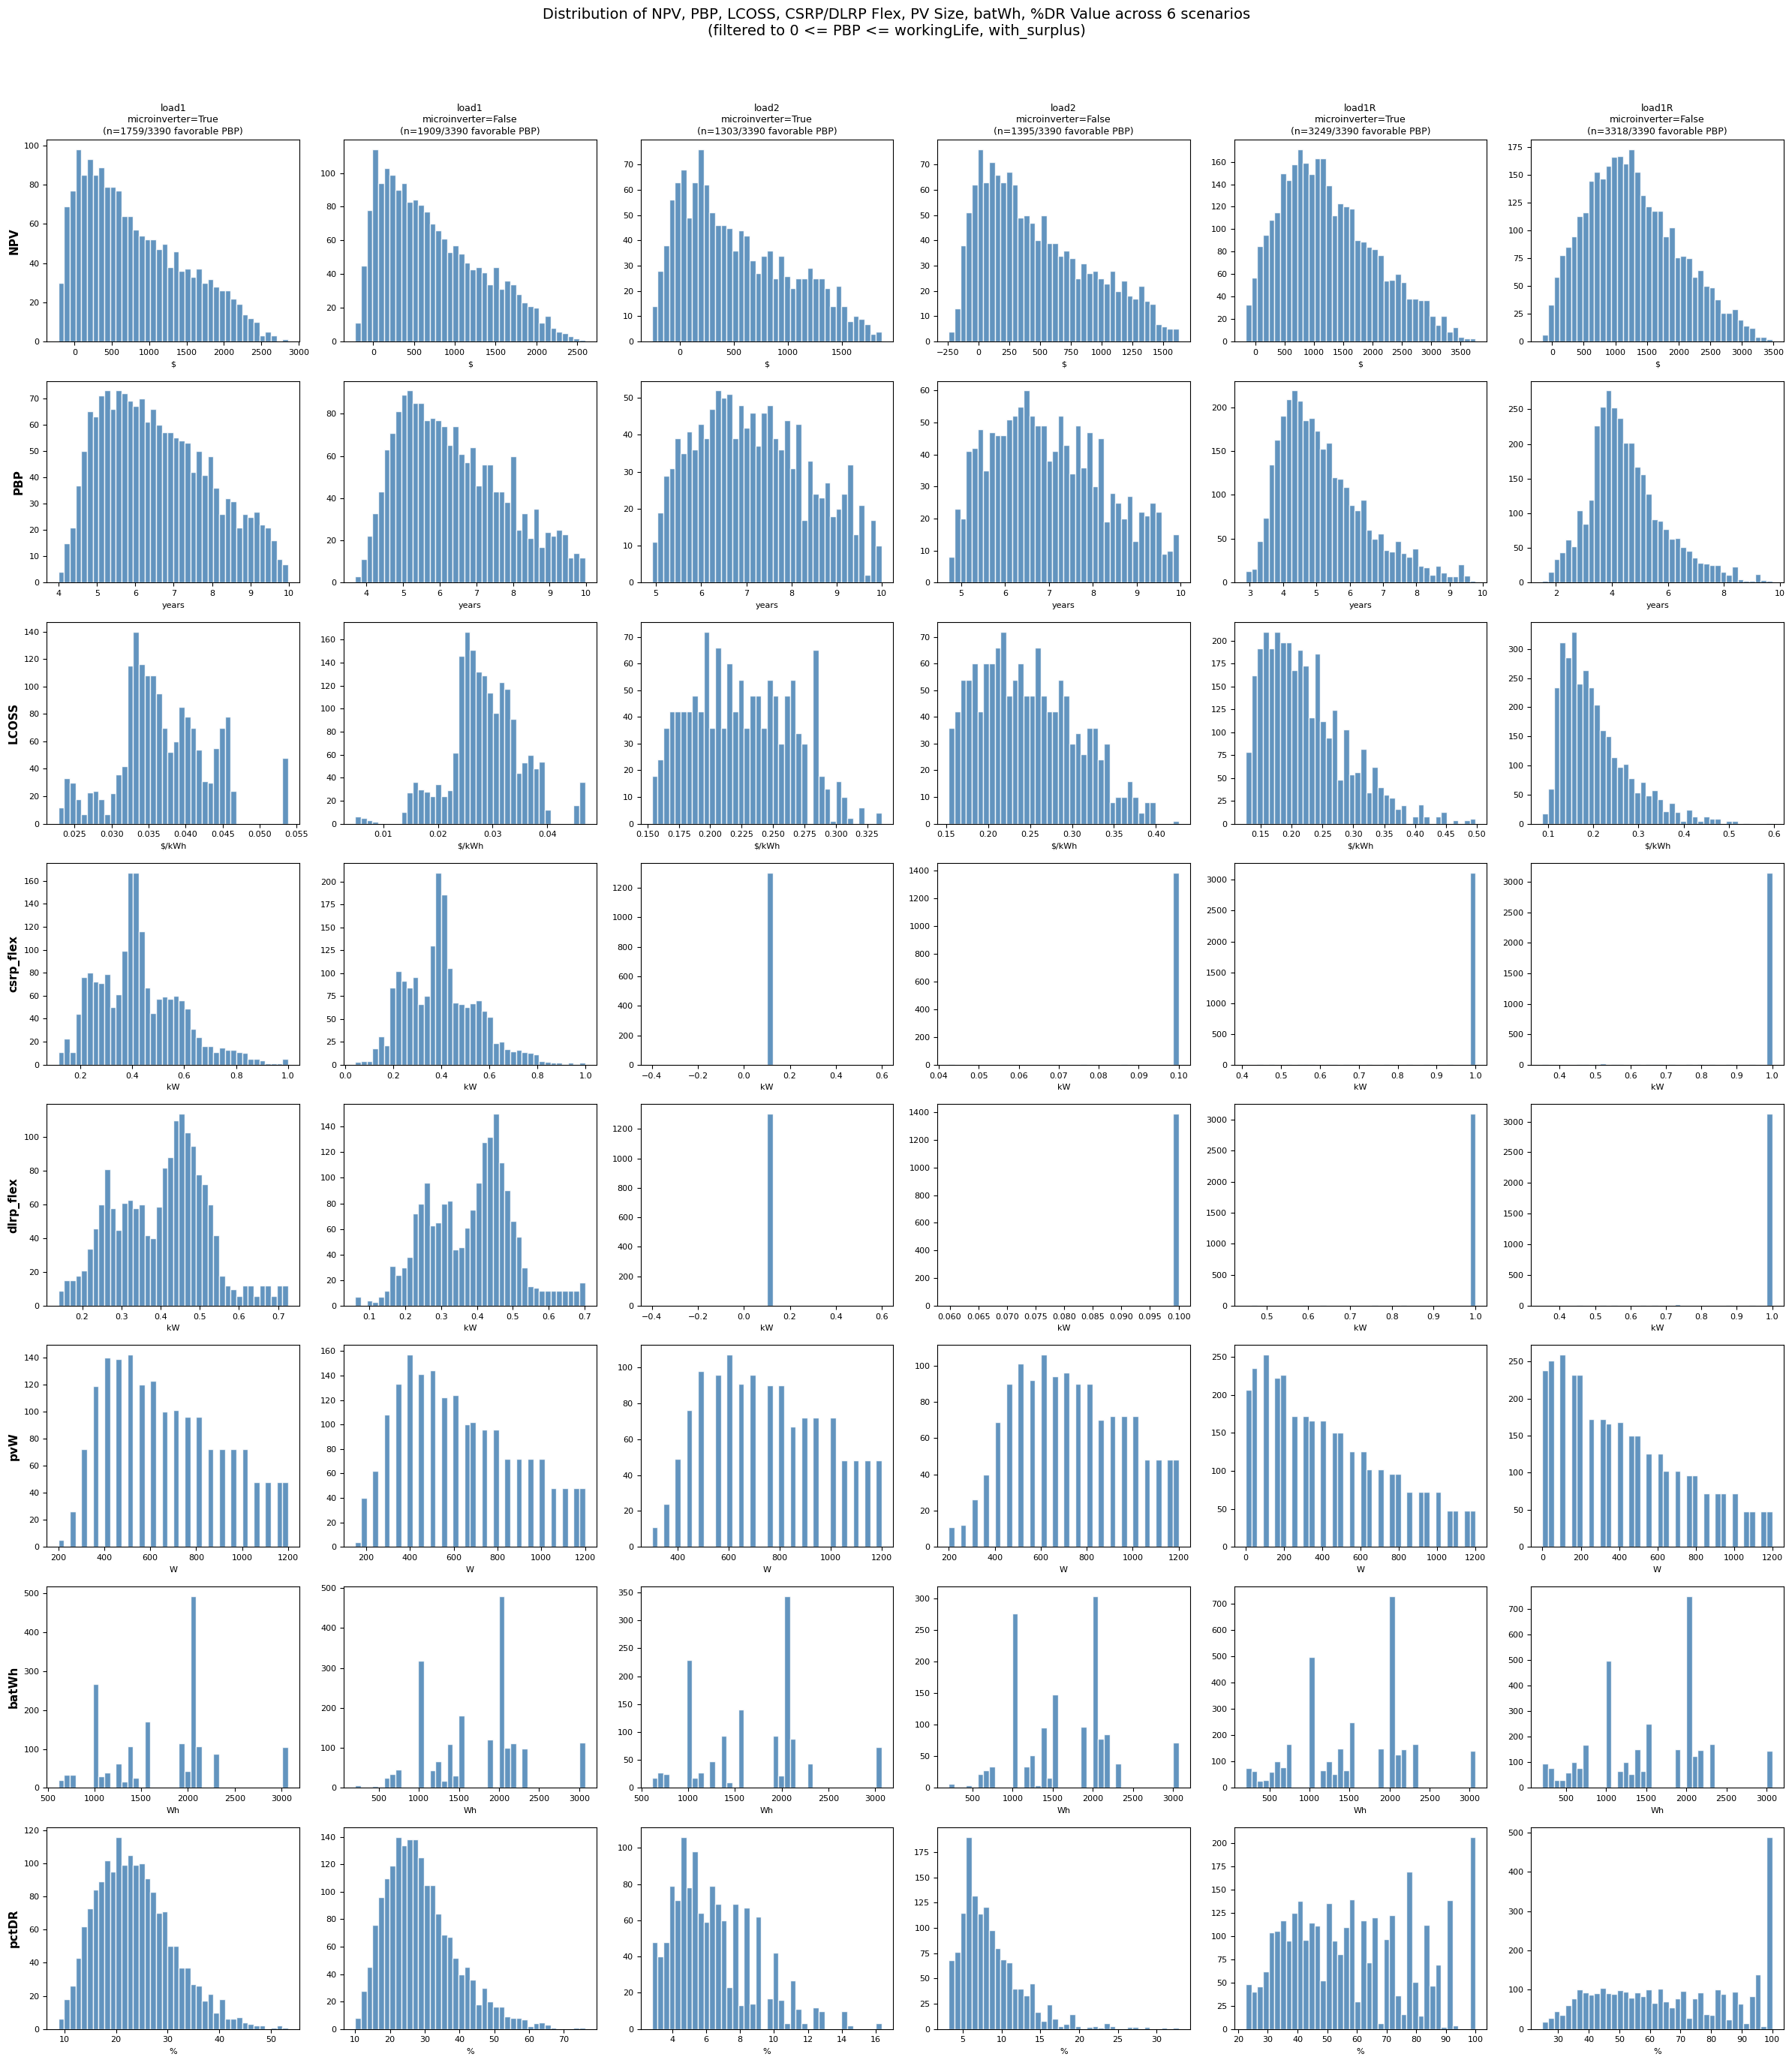

In [43]:
# Histogram grid: NPV, PBP, LCOSS, CSRP/DLRP flex, PV size, batWh, %DR value across 6 scenarios,
# filtered to rows where 0 <= PBP <= workingLife (genuinely favorable payback)
LOADS = ["load1", "load2", "load1R"]
METRICS = ["NPV", "PBP", "LCOSS"]
#FLEX_METRICS = ['csrpLoad1_flex','csrpLoad2_flex','csrpLoad1replacement_flex','dlrpLoad1_flex','dlrpLoad2_flex','dlrpLoad1replacement_flex']#["csrpMaxFlex", "dlrpMaxFlex"]

# Map each load to its own pair of flex columns (they're load-specific, not shared like csrpMaxFlex was)
LOAD_FLEX_MAP = {
    "load1":  ["csrpLoad1_flex", "dlrpLoad1_flex"],
    "load2":  ["csrpLoad2_flex", "dlrpLoad2_flex"],
    "load1R": ["csrpLoad1replacement_flex", "dlrpLoad1replacement_flex"],
}
FLEX_ROW_LABELS = ["csrp_flex", "dlrp_flex"]  # generic row labels; actual column resolved per load

SCALAR_METRICS = ["pvW", "batWh"]
VALUE_METRICS = ["pctDR"]
SURPLUS_KEY = "with_surplus"  # change to "without_surplus" to see the other case

# Unit labels for each metric, for x-axis annotation
UNITS = {
    "NPV": "$",
    "PBP": "years",
    "LCOSS": "$/kWh",
    "csrp_flex": "kW",
    "dlrp_flex": "kW",
    "pvW": "W",
    "batWh": "Wh",
    "pctDR": "%",
}

def extract_metric(df, load, metric, surplus_key=SURPLUS_KEY):
    """Pull a flat numeric Series out of the {load}_{metric} dict column."""
    return df[f"{load}_{metric}"].apply(lambda d: d.get(surplus_key))

def pct_dr_value(df, load):
    """% of total system value attributable to DR income vs grid/PV avoidance."""
    dr_income_col = f"annDRIncomeLoad{load[4:]}"  # e.g. load1 -> annDRIncomeLoad1
    gv_col = f"gridValue_{load}"
    dr_value = df[dr_income_col].apply(np.sum)
    grid_pv_value = df[gv_col].apply(
        lambda d: np.sum(d["ann_surpluskWhAC_value"]) + np.sum(d["avoidedGridkWhAC_value"])
    )
    total_value = dr_value + grid_pv_value
    return pd.Series(np.where(total_value != 0, dr_value / total_value * 100, np.nan), index=df.index)

scenarios = [(load, mi) for load in LOADS for mi in [True, False]]
all_rows = METRICS + FLEX_ROW_LABELS + SCALAR_METRICS + VALUE_METRICS

fig, axs = plt.subplots(len(all_rows), len(scenarios), figsize=(24, 28))

for col, (load, mi) in enumerate(scenarios):
    subset = results_df[results_df["microinverter"] == mi]
    pbp = extract_metric(subset, load, "PBP")
    favorable = subset[(pbp >= 0) & (pbp <= subset["workingLife"])]
    n_before, n_after = len(subset), len(favorable)

    for row, metric in enumerate(all_rows):
        ax = axs[row, col]
        if metric in FLEX_ROW_LABELS:
            flex_idx = FLEX_ROW_LABELS.index(metric)
            actual_col = LOAD_FLEX_MAP[load][flex_idx]  # resolve to the right load-specific column
            vals = favorable[actual_col].apply(np.mean).dropna()
            #vals = favorable[metric].apply(np.mean).dropna()
        elif metric in SCALAR_METRICS:
            vals = favorable[metric].dropna()
        elif metric == "pctDR":
            vals = pct_dr_value(favorable, load).dropna()
        else:
            vals = extract_metric(favorable, load, metric).dropna()
        ax.hist(vals, bins=40, facecolor="steelblue", edgecolor="white", alpha=0.85)
        if row == 0:
            ax.set_title(f"{load}\nmicroinverter={mi}\n(n={n_after}/{n_before} favorable PBP)", fontsize=9)
        if col == 0:
            ax.set_ylabel(metric, fontsize=11, fontweight="bold")
        ax.set_xlabel(UNITS[metric], fontsize=8)   # <-- units added here
        ax.tick_params(labelsize=8)

fig.suptitle(f"Distribution of NPV, PBP, LCOSS, CSRP/DLRP Flex, PV Size, batWh, %DR Value across 6 scenarios\n"
             f"(filtered to 0 <= PBP <= workingLife, {SURPLUS_KEY})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [45]:
print("Favorable PBP counts by scenario:")
for load in LOADS:
    for mi in [True, False]:
        subset = results_df[results_df["microinverter"] == mi]
        pbp = extract_metric(subset, load, "PBP")
        favorable = subset[(pbp >= 0) & (pbp <= subset["workingLife"])]
        print(f"  {load:8s} mi={mi!s:5s}: n={len(favorable):4d} / {len(subset)}")

Favorable PBP counts by scenario:
  load1    mi=True : n=1759 / 3390
  load1    mi=False: n=1909 / 3390
  load2    mi=True : n=1303 / 3390
  load2    mi=False: n=1395 / 3390
  load1R   mi=True : n=3249 / 3390
  load1R   mi=False: n=3318 / 3390


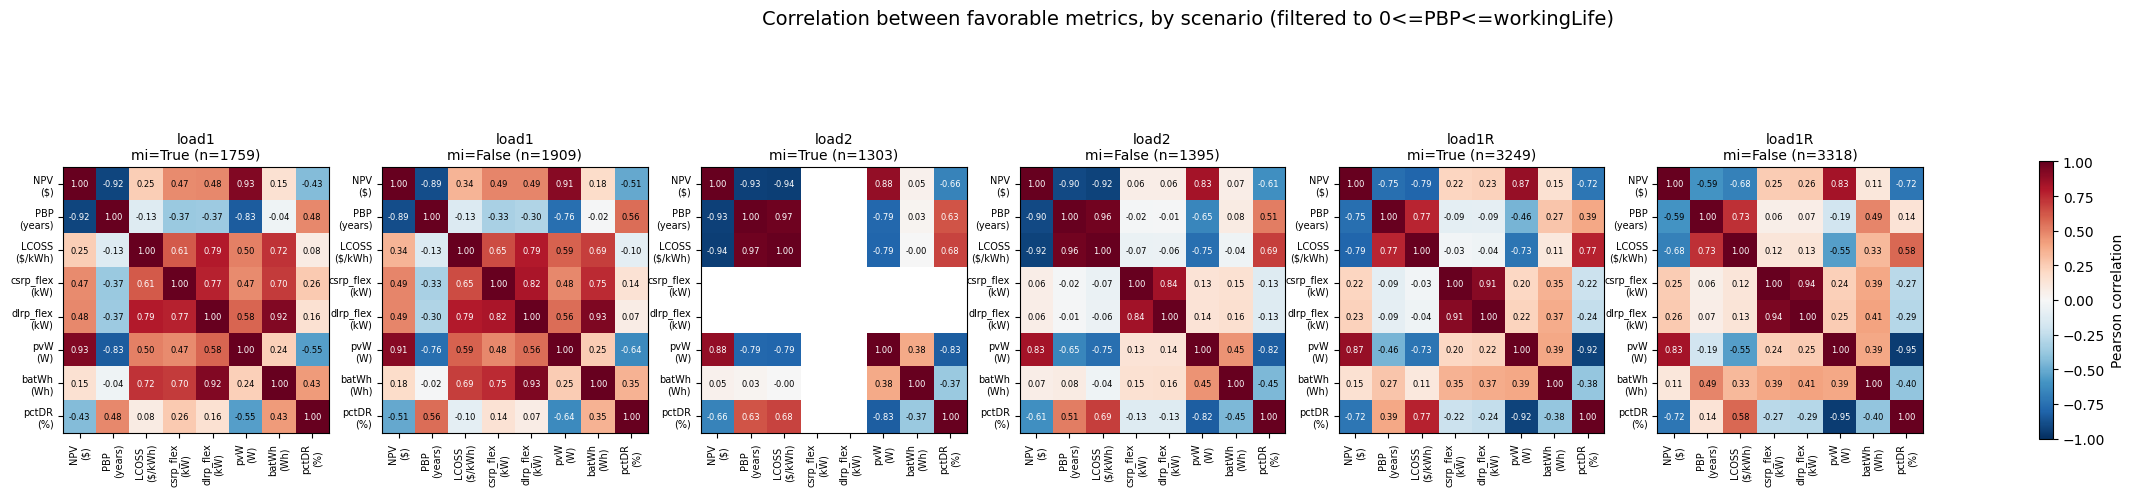

In [44]:
# # Correlation heatmaps: co-existence of favorable metrics across 6 scenarios
# # (filtered to 0 <= PBP <= workingLife, as before)

# def pct_dr_value(df, load):
#     """% of total system value attributable to DR income vs grid/PV avoidance."""
#     dr_income_col = f"annDRIncomeLoad{load[4:]}"
#     gv_col = f"gridValue_{load}"
#     dr_value = df[dr_income_col].apply(np.sum)
#     grid_pv_value = df[gv_col].apply(
#         lambda d: np.sum(d["ann_surpluskWhAC_value"]) + np.sum(d["avoidedGridkWhAC_value"])
#     )
#     total_value = dr_value + grid_pv_value
#     return pd.Series(np.where(total_value != 0, dr_value / total_value * 100, np.nan), index=df.index)

# def build_scenario_metrics_df(df, load, mi):
#     """Flat numeric dataframe of all favorable-PBP metrics for one (load, mi) scenario."""
#     subset = df[df["microinverter"] == mi].copy()
#     out = pd.DataFrame(index=subset.index)
#     out["NPV"] = extract_metric(subset, load, "NPV")
#     out["PBP"] = extract_metric(subset, load, "PBP")
#     out["LCOSS"] = extract_metric(subset, load, "LCOSS")
#     out["csrpFlex"] = subset["csrpMaxFlex"].apply(np.mean)
#     out["dlrpFlex"] = subset["dlrpMaxFlex"].apply(np.mean)
#     out["pvW"] = subset["pvW"]
#     out["batWh"] = subset["batWh"]
#     out["pctDR"] = pct_dr_value(subset, load)
#     favorable_mask = (out["PBP"] >= 0) & (out["PBP"] <= subset["workingLife"])
#     return out[favorable_mask]

# scenarios = [(load, mi) for load in LOADS for mi in [True, False]]

# fig, axs = plt.subplots(1, len(scenarios), figsize=(30, 6))

# for col, (load, mi) in enumerate(scenarios):
#     m = build_scenario_metrics_df(results_df, load, mi)
#     corr = m.corr()
#     ax = axs[col]
#     im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
#     ax.set_xticks(range(len(corr.columns)))
#     ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
#     ax.set_yticks(range(len(corr.columns)))
#     ax.set_yticklabels(corr.columns, fontsize=8)
#     for i in range(len(corr.columns)):
#         for j in range(len(corr.columns)):
#             val = corr.iloc[i, j]
#             if not np.isnan(val):
#                 ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6,
#                         color="white" if abs(val) > 0.6 else "black")
#     ax.set_title(f"{load}\nmi={mi} (n={len(m)})", fontsize=10)

# fig.colorbar(im, ax=axs, shrink=0.6, label="Pearson correlation")
# fig.suptitle("Correlation between favorable metrics, by scenario (filtered to 0<=PBP<=workingLife)", fontsize=14)
# plt.show()

# Correlation heatmaps: co-existence of favorable metrics across 6 scenarios
# (filtered to 0 <= PBP <= workingLife, as before)

def build_scenario_metrics_df(df, load, mi):
    """Flat numeric dataframe of all favorable-PBP metrics for one (load, mi) scenario."""
    subset = df[df["microinverter"] == mi].copy()
    csrp_col, dlrp_col = LOAD_FLEX_MAP[load]  # load-specific flex columns
    out = pd.DataFrame(index=subset.index)
    out["NPV"] = extract_metric(subset, load, "NPV")
    out["PBP"] = extract_metric(subset, load, "PBP")
    out["LCOSS"] = extract_metric(subset, load, "LCOSS")
    out["csrp_flex"] = subset[csrp_col].apply(np.mean)
    out["dlrp_flex"] = subset[dlrp_col].apply(np.mean)
    out["pvW"] = subset["pvW"]
    out["batWh"] = subset["batWh"]
    out["pctDR"] = pct_dr_value(subset, load)
    favorable_mask = (out["PBP"] >= 0) & (out["PBP"] <= subset["workingLife"])
    return out[favorable_mask]

scenarios = [(load, mi) for load in LOADS for mi in [True, False]]
fig, axs = plt.subplots(1, len(scenarios), figsize=(30, 6))

for col, (load, mi) in enumerate(scenarios):
    m = build_scenario_metrics_df(results_df, load, mi)
    corr = m.corr()
    labels_with_units = [f"{c}\n({UNITS[c]})" for c in corr.columns]  # <-- units added here

    ax = axs[col]
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(labels_with_units, rotation=90, fontsize=7)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(labels_with_units, fontsize=7)
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if abs(val) > 0.6 else "black")
    ax.set_title(f"{load}\nmi={mi} (n={len(m)})", fontsize=10)

fig.colorbar(im, ax=axs, shrink=0.6, label="Pearson correlation")
fig.suptitle("Correlation between favorable metrics, by scenario (filtered to 0<=PBP<=workingLife)", fontsize=14)
plt.show()

In [52]:
# # Network comparison: 6 scenarios x with/without surplus, 8 metrics,
# # filtered to 0 <= PBP <= workingLife computed separately per surplus variant
# SURPLUS_KEYS = ["with_surplus", "without_surplus"]

# def extract_metric(df, load, metric, surplus_key):
#     return df[f"{load}_{metric}"].apply(lambda d: d.get(surplus_key))

# def get_metric_values(df, load, metric, surplus_key):
#     if metric in FLEX_METRICS:
#         return df[metric].apply(np.mean)
#     elif metric in SCALAR_METRICS:
#         return df[metric]
#     elif metric == "pctDR":
#         return pct_dr_value(df, load)  # not surplus-dependent; gridValue doesn't split by surplus
#     else:
#         return extract_metric(df, load, metric, surplus_key)

# NETWORKS = sorted(results_df["network"].unique())
# # surplus is now a third scenario dimension -> 3 loads x 2 mi x 2 surplus = 12 columns
# scenarios = [(load, mi, sk) for load in LOADS for mi in [True, False] for sk in SURPLUS_KEYS]
# all_rows = METRICS + FLEX_METRICS + SCALAR_METRICS + VALUE_METRICS  # 8 metrics
# palette = plt.cm.tab10(np.linspace(0, 1, len(NETWORKS)))

# fig, axs = plt.subplots(len(all_rows), len(scenarios), figsize=(48, 32), sharey="row")

# for col, (load, mi, sk) in enumerate(scenarios):
#     subset = results_df[results_df["microinverter"] == mi]
#     pbp = extract_metric(subset, load, "PBP", sk)
#     favorable = subset[(pbp >= 0) & (pbp <= subset["workingLife"])]
#     n_before, n_after = len(subset), len(favorable)

#     for row, metric in enumerate(all_rows):
#         ax = axs[row, col]
#         vals = get_metric_values(favorable, load, metric, sk)
#         data = [vals[favorable["network"] == net].dropna() for net in NETWORKS]
#         bp = ax.boxplot(data, tick_labels=NETWORKS, patch_artist=True, widths=0.6)
#         for patch, c in zip(bp["boxes"], palette):
#             patch.set_facecolor(c)
#             patch.set_alpha(0.75)
#         if row == 0:
#             ax.set_title(f"{load} | mi={mi}\n{sk}\n(n={n_after}/{n_before} favorable)", fontsize=8)
#         if col == 0:
#             ax.set_ylabel(metric, fontsize=11, fontweight="bold")
#         ax.tick_params(labelsize=6, axis="x", rotation=45)

# fig.suptitle(f"Network comparison: {len(NETWORKS)} networks x 6 scenarios x with/without surplus, 8 metrics\n"
#              f"(filtered to 0<=PBP<=workingLife per surplus variant, shared scale per metric)", fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show()

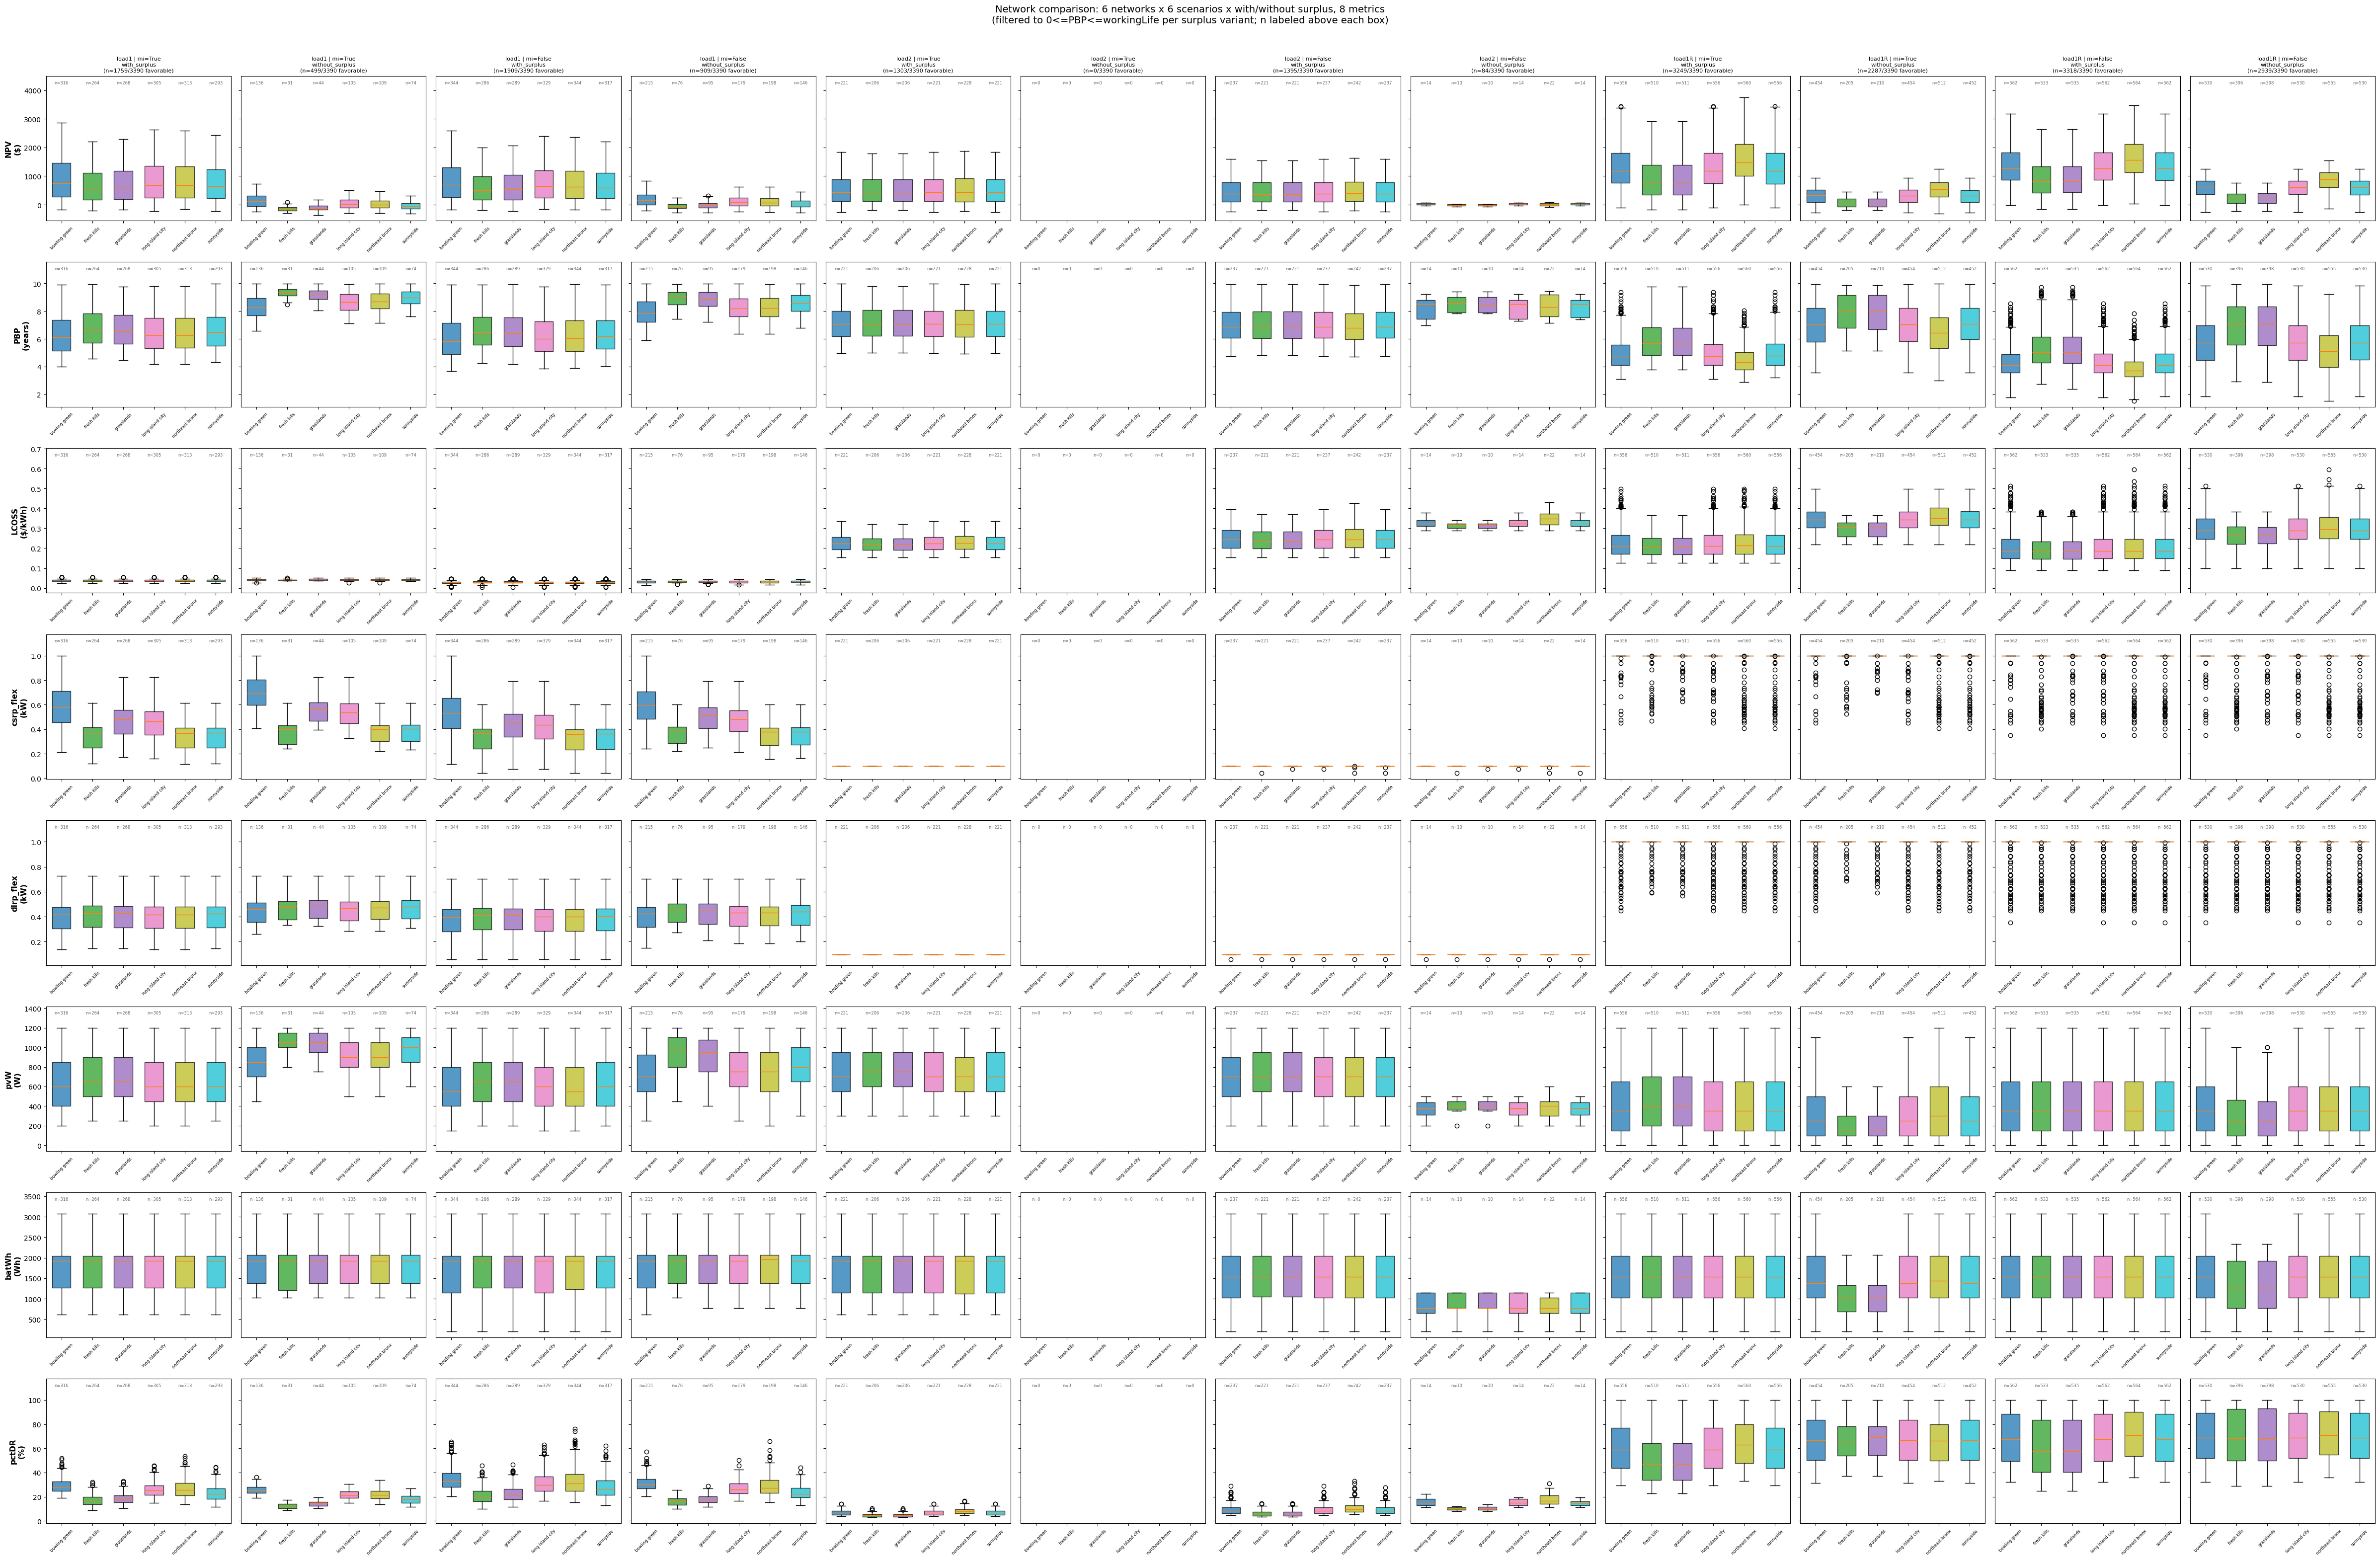

In [57]:
# Network comparison: 6 scenarios x with/without surplus, 8 metrics,
# filtered to 0 <= PBP <= workingLife computed separately per surplus variant
SURPLUS_KEYS = ["with_surplus", "without_surplus"]

def extract_metric(df, load, metric, surplus_key):
    return df[f"{load}_{metric}"].apply(lambda d: d.get(surplus_key))

def get_metric_values(df, load, metric, surplus_key):
    if metric in FLEX_ROW_LABELS:
        flex_idx = FLEX_ROW_LABELS.index(metric)
        actual_col = LOAD_FLEX_MAP[load][flex_idx]  # resolve to the right load-specific column
        return df[actual_col].apply(np.mean)
    elif metric in SCALAR_METRICS:
        return df[metric]
    elif metric == "pctDR":
        return pct_dr_value(df, load)  # not surplus-dependent; gridValue doesn't split by surplus
    else:
        return extract_metric(df, load, metric, surplus_key)

NETWORKS = sorted(results_df["network"].unique())
# surplus is now a third scenario dimension -> 3 loads x 2 mi x 2 surplus = 12 columns
scenarios = [(load, mi, sk) for load in LOADS for mi in [True, False] for sk in SURPLUS_KEYS]
all_rows = METRICS + FLEX_ROW_LABELS + SCALAR_METRICS + VALUE_METRICS  # 8 metrics, uses generic flex labels
palette = plt.cm.tab10(np.linspace(0, 1, len(NETWORKS)))

# Boxes colored by network, n labeled above each box with proper headroom
palette = plt.cm.tab10(np.linspace(0, 1, len(NETWORKS)))

fig, axs = plt.subplots(len(all_rows), len(scenarios), figsize=(48, 32), sharey="row")

# store counts per (row, col) so we can add labels after fixing each row's ylim
counts_grid = {}

for col, (load, mi, sk) in enumerate(scenarios):
    subset = results_df[results_df["microinverter"] == mi]
    pbp = extract_metric(subset, load, "PBP", sk)
    favorable = subset[(pbp >= 0) & (pbp <= subset["workingLife"])]
    n_before, n_after = len(subset), len(favorable)

    for row, metric in enumerate(all_rows):
        ax = axs[row, col]
        vals = get_metric_values(favorable, load, metric, sk)
        data = [vals[favorable["network"] == net].dropna() for net in NETWORKS]
        counts = [len(d) for d in data]
        counts_grid[(row, col)] = counts
        bp = ax.boxplot(data, tick_labels=NETWORKS, patch_artist=True, widths=0.6)
        for patch, c in zip(bp["boxes"], palette):
            patch.set_facecolor(c)
            patch.set_alpha(0.75)

        if row == 0:
            ax.set_title(f"{load} | mi={mi}\n{sk}\n(n={n_after}/{n_before} favorable)", fontsize=8)
        if col == 0:
            #ax.set_ylabel(metric, fontsize=11, fontweight="bold")
            ax.set_ylabel(f"{metric}\n({UNITS[metric]})", fontsize=11, fontweight="bold")  # <-- units added here
        ax.tick_params(labelsize=6, axis="x", rotation=45)

# second pass: expand each row's shared ylim ONCE (after all its columns are drawn) and add labels
for row in range(len(all_rows)):
    ylim = axs[row, 0].get_ylim()  # shared across the row
    span = ylim[1] - ylim[0]
    new_top = ylim[1] + 0.12 * span
    axs[row, 0].set_ylim(ylim[0], new_top)  # propagates to whole row via sharey
    y_label_pos = new_top - 0.03 * (new_top - ylim[0])
    for col in range(len(scenarios)):
        ax = axs[row, col]
        for i, n in enumerate(counts_grid[(row, col)]):
            ax.text(i + 1, y_label_pos, f"n={n}", ha="center", va="top", fontsize=6, color="dimgray")

fig.suptitle(f"Network comparison: {len(NETWORKS)} networks x 6 scenarios x with/without surplus, 8 metrics\n"
             f"(filtered to 0<=PBP<=workingLife per surplus variant; n labeled above each box)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
fig.savefig(f"results/plots/network_comparison_{timestamp}.png", dpi=300, bbox_inches="tight")

plt.show()

# Old

In [50]:
# summerize lists,
avgCols = ['csrpMaxFlex','dlrpMaxFlex','csrpLoad1_percentage','csrpLoad2_percentage','csrpLoad1replacement_percentage','dlrpLoad1_percentage','dlrpLoad2_percentage','dlrpLoad1replacement_percentage']
for c in avgCols:
    analyze_plugin_df[c] = analyze_plugin_df[c].apply(np.mean)
    analyze_offgrid_df[c] = analyze_offgrid_df[c].apply(np.mean)

C:\Users\alexn\AppData\Local\Temp\ipykernel_44528\471737142.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analyze_plugin_df[c] = analyze_plugin_df[c].apply(np.mean)
C:\Users\alexn\AppData\Local\Temp\ipykernel_44528\471737142.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analyze_offgrid_df[c] = analyze_offgrid_df[c].apply(np.mean)


In [51]:
analyze_plugin_df.describe()

,pvW,batWh,batWhAC,capex,workingLife,csrpMaxFlex,dlrpMaxFlex,csrpLoad1_percentage,csrpLoad2_percentage,csrpLoad1replacement_percentage,dlrpLoad1_percentage,dlrpLoad2_percentage,dlrpLoad1replacement_percentage
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,163.207547,1268.370189,870.107955,1298.004771,9.113466,0.252889,0.233636,0.252889,2.528886,3.371848,0.233636,2.336363,3.115151
std,273.064224,755.645503,511.547859,509.614290,0.897478,0.178919,0.150269,0.178919,1.789192,2.385589,0.150269,1.502694,2.003592
min,0.000000,204.000000,146.880000,516.067500,6.849315,0.026370,0.026370,0.026370,0.263700,0.351600,0.026370,0.263700,0.351600
25%,0.000000,614.000000,417.520000,891.130988,8.219178,0.105988,0.098216,0.105988,1.059882,1.413176,0.098216,0.982157,1.309543
50%,100.000000,1152.000000,829.440000,1200.335988,9.589041,0.212042,0.204407,0.212042,2.120425,2.827233,0.204407,2.044069,2.725425
75%,100.000000,2042.800000,1389.104000,1578.687500,10.000000,0.359415,0.355259,0.359415,3.594150,4.792200,0.355259,3.552587,4.736782
max,800.000000,3072.000000,2088.960000,2808.975000,10.000000,0.887479,0.654526,0.887479,8.874788,11.833051,0.654526,6.545263,8.727018


In [52]:
analyze_offgrid_df.describe()

,pvW,batWh,batWhAC,capex,workingLife,csrpMaxFlex,dlrpMaxFlex,csrpLoad1_percentage,csrpLoad2_percentage,csrpLoad1replacement_percentage,dlrpLoad1_percentage,dlrpLoad2_percentage,dlrpLoad1replacement_percentage
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,163.207547,1268.370189,870.107955,944.161021,9.113466,0.248030,0.230554,0.248030,2.480301,3.307068,0.230554,2.305544,3.074059
std,273.064224,755.645503,511.547859,509.614290,0.897478,0.171339,0.147089,0.171339,1.713387,2.284516,0.147089,1.470892,1.961189
min,0.000000,204.000000,146.880000,162.223750,6.849315,0.026370,0.026370,0.026370,0.263700,0.351600,0.026370,0.263700,0.351600
25%,0.000000,614.000000,417.520000,537.287238,8.219178,0.105804,0.097665,0.105804,1.058041,1.410721,0.097665,0.976650,1.302200
50%,100.000000,1152.000000,829.440000,846.492238,9.589041,0.211619,0.204407,0.211619,2.116187,2.821582,0.204407,2.044069,2.725425
75%,100.000000,2042.800000,1389.104000,1224.843750,10.000000,0.358290,0.353231,0.358290,3.582900,4.777200,0.353231,3.532306,4.709741
max,800.000000,3072.000000,2088.960000,2455.131250,10.000000,0.844648,0.638301,0.844648,8.446483,11.261977,0.638301,6.383014,8.510686


In [53]:
gridValueKeys = ['avg_hourly_surpluskWAC_byMonth','med_hourly_surpluskWAC_byMonth','min_hourly_surpluskWAC_byMonth',
                 'max_hourly_surpluskWAC_byMonth',
                 'ann_surpluskWhAC','ann_surpluskWhAC_value','requiredGridkWhAC',
                 'requiredGridkWhAC_cost','eventGridChargekWhAC','eventGridChargekWhAC_costs',
                 'avoidedGridkWhAC','avoidedGridkWhAC_value']

scenarios = ['with_surplus', 'without_surplus']
baselines = ['1','2','1R']
colsN = [f'load{b}_NPV' for b in baselines]
colsP = [f'load{b}_PBP' for b in baselines]
colsL = [f'load{b}_LCOSS' for b in baselines]
colsGridValue = [f'gridValue_load{b}' for b in baselines]

In [54]:
# break out and summerize dictionaries

expAnalyze_df = analyze_plugin_df
for c in colsN:
    expanded = analyze_plugin_df[c].apply(pd.Series) # break out dictionaries into their own columns
    for s in scenarios:
        expanded = expanded.rename(columns={s: f'{c}-{s}'})
    expAnalyze_df = pd.concat([expAnalyze_df, expanded],axis=1)
    
for c in colsP:
    expanded = analyze_plugin_df[c].apply(pd.Series) # break out dictionaries into their own columns
    for s in scenarios:
        expanded = expanded.rename(columns={s: f'{c}-{s}'})
    expAnalyze_df = pd.concat([expAnalyze_df, expanded],axis=1)

for c in colsL:
    expanded = analyze_plugin_df[c].apply(pd.Series) # break out dictionaries into their own columns
    for s in scenarios:
        expanded = expanded.rename(columns={s: f'{c}-{s}'})
    expAnalyze_df = pd.concat([expAnalyze_df, expanded],axis=1)

for c in colsGridValue:
    expanded = analyze_plugin_df[c].apply(pd.Series) # break out dictionaries into their own columns
    for s in gridValueKeys:
        expanded = expanded.rename(columns={s: f'{c}-{s}'})
    expAnalyze_df = pd.concat([expAnalyze_df, expanded],axis=1)
    
expAnalyze_df = expAnalyze_df.drop(columns=(colsN+colsP+colsL+colsGridValue))
expAnalyze_df.head()


,network,pvW,microinverter,batModel,batWh,batWhAC,capex,workingLife,csrpMaxFlex,dlrpMaxFlex,...,gridValue_load1R-ann_surpluskWhAC,gridValue_load1R-ann_surpluskWhAC_value,gridValue_load1R-requiredGridkWhAC,gridValue_load1R-requiredGridkWhAC_cost,gridValue_load1R-eventGridChargekWhAC,eventGridChargekWhAC_cost,eventBatteryOutputkWhAC_fromGrid,gridValue_load1R-avoidedGridkWhAC,gridValue_load1R-avoidedGridkWhAC_value,gridToLoadkWhAC
0,bowling green,0,True,Explorer 300 Plus,288.00,195.8400,873.710988,8.219178,0.039185,0.039185,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[52.37658947368422, 52.37658947368422, 52.3765...","[15.524421120000003, 15.834909542400002, 16.15...","[1.44, 1.44, 1.44, 1.44, 1.44, 1.44, 1.44, 1.4...","[0.422496, 0.4309459199999999, 0.4395648383999...","[1.1627999999999998, 1.1627999999999998, 1.162...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[656.97042, 656.97042, 656.97042, 656.97042, 6..."
1,bowling green,100,True,Explorer 300 Plus,288.00,195.8400,1010.893487,8.219178,0.086294,0.057031,...,"[0.49973978220622534, 0.4036401685039334, 0.32...","[0.14812287144592517, 0.12203172486345717, 0.0...","[52.37658947368422, 52.37658947368422, 52.3765...","[15.524421120000003, 15.834909542400002, 16.15...","[1.44, 1.44, 1.44, 1.44, 1.44, 1.44, 1.44, 1.4...","[0.422496, 0.4309459199999999, 0.4395648383999...","[1.1627999999999998, 1.1627999999999998, 1.162...","[129.4510950160757, 128.24768628179518, 127.04...","[38.36930456276484, 38.772866498202575, 39.176...","[527.5193249839243, 528.722733718205, 529.9276..."
4,bowling green,0,True,Explorer 600 Plus,632.00,429.7600,1015.248488,10.000000,0.097665,0.097665,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[45.68941052631581, 45.68941052631581, 45.6894...","[13.542341280000006, 13.813188105600005, 14.08...","[3.1600000000000006, 3.1600000000000006, 3.160...","[0.9271440000000002, 0.9456868800000001, 0.964...","[2.5517000000000003, 2.5517000000000003, 2.551...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[610.57385, 610.57385, 610.57385, 610.57385, 6..."
5,bowling green,100,True,Explorer 600 Plus,632.00,429.7600,1152.430987,10.000000,0.144542,0.115423,...,"[0.49973978220622534, 0.4036401685039334, 0.32...","[0.14812287144592517, 0.12203172486345717, 0.0...","[45.68941052631581, 45.68941052631581, 45.6894...","[13.542341280000006, 13.813188105600005, 14.08...","[3.1600000000000006, 3.1600000000000006, 3.160...","[0.9271440000000002, 0.9456868800000001, 0.964...","[2.5517000000000003, 2.5517000000000003, 2.551...","[129.4510950160757, 128.24768628179518, 127.04...","[38.36930456276484, 38.772866498202575, 39.176...","[481.1227549839242, 482.32616371820484, 483.53..."
8,bowling green,0,True,Explorer 700 Plus,680.96,463.0528,1200.335988,10.000000,0.105988,0.105988,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[47.05201401857586, 47.05201401857586, 47.0520...","[13.946216955105886, 14.225141294208003, 14.50...","[3.4048000000000007, 3.4048000000000007, 3.404...","[0.9989683200000002, 1.0189476864000002, 1.039...","[2.7493760000000003, 2.7493760000000003, 2.749...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[602.1015854, 602.1015854, 602.1015854, 602.10..."


## Important Metrics by Scenario

In [ ]:
load1_expAnalyze_df.head()

In [ ]:
load1_expAnalyze_df.info()

In [ ]:
colsN+colsP+colsL+colsGridValue

In [ ]:
load1_expAnalyze_df[load1_expAnalyze_df['load1_PBP-without_surplus']>load1_expAnalyze_df['workingLife']][['workingLife','load1_PBP-without_surplus','load1_NPV-without_surplus','pvW','batWh']]

In [ ]:
scenarios = ['without_surplus', 'with_surplus']
loads = ['1','2','1R']
#baseline_scenarios = [f'load{b}_NPV-{s}' for b in baselines for s in scenarios]
#print(baseline_scenarios)
plot_results = ['npv','pbp','lcoss','csrp','dlrp','avg hourly surplus','capex','pvW','batWh']
units = ['$','years','$/kWh','kW','kW','kWAC','$','WDC','WhDC']

fig, axs = plt.subplots(len(plot_results),1, figsize=(14, 30))#, sharey=True to have identical heights

for ir, r in enumerate(plot_results): # category to plot
    boxPlotData = []
    myLabels=[]
    for il, l in enumerate(loads):
        for isc, sc in enumerate(scenarios):# with or without surplus
            if l == '1':
                data = load1_expAnalyze_df[(load1_expAnalyze_df[f'load{l}_NPV-{sc}']>=0)]# & (load1_expAnalyze_df[f'load{l}_PBP-{sc}']<=load1_expAnalyze_df['workingLife'])]
            elif l == '2':
                data = load2_expAnalyze_df[(load2_expAnalyze_df[f'load{l}_NPV-{sc}']>=0)]# & (load2_expAnalyze_df[f'load{l}_PBP-{sc}']<=load2_expAnalyze_df['workingLife'])]
            elif l == '1R':
                data = load1R_expAnalyze_df[(load1R_expAnalyze_df[f'load{l}_NPV-{sc}']>=0)]# & (load1R_expAnalyze_df[f'load{l}_PBP-{sc}']<=load1R_expAnalyze_df['workingLife'])]
            
            #print(f'{r}-{b}')
            if r == 'npv':
                bb = f'load{l}_NPV-{sc}'
            elif r == 'pbp':
                bb = f'load{l}_PBP-{sc}'
            elif r == 'lcoss':
                bb = f'load{l}_LCOSS-{sc}'
            elif (r == 'csrp') | (r == 'dlrp'):
                if sc == 'with_surplus':
                    bb = f'{r}MaxFlex'
                else:
                    bb = f'{r}Load{l}_kWflex'
            elif r == 'avg hourly surplus':
                bb = f'gridValue_load{l}-med_hourly_surpluskWAC_byMonth' #gridValue_load1-med_hourly_surpluskWAC_byMonth
            else:
                bb = r
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            if r == 'avg hourly surplus':
                boxPlotData.append(list([mean(s) for s in data[bb]]))
            else:
                boxPlotData.append(list(data[bb]))
            myLabels.append(bb)

    axs[ir].boxplot(boxPlotData, tick_labels=myLabels)
    for label in axs[ir].get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment('right')
        
    axs[ir].set_title(f'{r}')
    axs[ir].set_ylabel(f'{units[ir]}') 

    # draw line to indicate comparison
    if r in ['csrp','dlrp']:
        axs[ir].axhline(0.5, c='r')

#fig.subplots_adjust(bottom=0.05, top=0.9,hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
fig.suptitle('Positive NPV Result - Characteristics by Scenario')

plt.savefig(f"results/{directory}/positiveNPVs_{datetime.now().timestamp()}.png")
plt.show()


In [ ]:
scenarios = ['without_surplus', 'with_surplus']
loads = ['1','2','1R']
#baseline_scenarios = [f'load{b}_NPV-{s}' for b in baselines for s in scenarios]
#print(baseline_scenarios)
plot_results = ['npv','pbp','lcoss','csrp','dlrp','avg hourly surplus','capex','pvW','batWh']
units = ['$','years','$/kWh','kW','kW','kWAC','$','WDC','WhDC']

fig, axs = plt.subplots(len(plot_results),1, figsize=(14, 30))#, sharey=True to have identical heights

for ir, r in enumerate(plot_results): # category to plot
    boxPlotData = []
    myLabels=[]
    for il, l in enumerate(loads):
        for isc, sc in enumerate(scenarios):# with or without surplus
            if l == '1':
                data = load1_expAnalyze_df[(load1_expAnalyze_df[f'load{l}_PBP-{sc}']>=0) & (load1_expAnalyze_df[f'load{l}_PBP-{sc}']<=load1_expAnalyze_df['workingLife'])]
            elif l == '2':
                data = load2_expAnalyze_df[(load2_expAnalyze_df[f'load{l}_PBP-{sc}']>=0) & (load2_expAnalyze_df[f'load{l}_PBP-{sc}']<=load2_expAnalyze_df['workingLife'])]
            elif l == '1R':
                data = load1R_expAnalyze_df[(load1R_expAnalyze_df[f'load{l}_PBP-{sc}']>=0) & (load1R_expAnalyze_df[f'load{l}_PBP-{sc}']<=load1R_expAnalyze_df['workingLife'])]
            
            #print(f'{r}-{b}')
            if r == 'npv':
                bb = f'load{l}_NPV-{sc}'
            elif r == 'pbp':
                bb = f'load{l}_PBP-{sc}'
            elif r == 'lcoss':
                bb = f'load{l}_LCOSS-{sc}'
            elif (r == 'csrp') | (r == 'dlrp'):
                if sc == 'with_surplus':
                    bb = f'{r}MaxFlex'
                else:
                    bb = f'{r}Load{l}_kWflex'
            elif r == 'avg hourly surplus':
                bb = f'gridValue_load{l}-med_hourly_surpluskWAC_byMonth' #gridValue_load1-med_hourly_surpluskWAC_byMonth
            else:
                bb = r
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            if r == 'avg hourly surplus':
                boxPlotData.append(list([mean(s) for s in data[bb]]))
            else:
                boxPlotData.append(list(data[bb]))
            myLabels.append(bb)

    axs[ir].boxplot(boxPlotData, tick_labels=myLabels)
    for label in axs[ir].get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment('right')
        
    axs[ir].set_title(f'{r}')
    axs[ir].set_ylabel(f'{units[ir]}') 

    # draw line to indicate comparison
    if r in ['csrp','dlrp']:
        axs[ir].axhline(0.5, c='r')

#fig.subplots_adjust(bottom=0.05, top=0.9,hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
fig.suptitle('Favorable PBPs - Characteristics by Scenario')

plt.savefig(f"results/{directory}/favorablePBP_{datetime.now().timestamp()}.png")
plt.show()


In [ ]:
#toggle for tax rate
t = '_notax'

scenarios = ['without_surplus', 'with_surplus']
loads = ['1','2','1R']
#baseline_scenarios = [f'load{b}_NPV-{s}' for b in baselines for s in scenarios]
#print(baseline_scenarios)
plot_results = ['npv','pbp','lcoss','csrp','dlrp','avg hourly surplus',f'capex{t}','pvW','batWh']
units = ['$','years','$/kWh','kW','kW','kWAC','$','WDC','WhDC']

fig, axs = plt.subplots(len(plot_results),1, figsize=(14, 30))#, sharey=True to have identical heights

for ir, r in enumerate(plot_results): # category to plot
    boxPlotData = []
    myLabels=[]
    for il, l in enumerate(loads):
        for isc, sc in enumerate(scenarios):# with or without surplus
            if l == '1':
                data = load1_expAnalyze_df[(load1_expAnalyze_df[f'load{l}_NPV-{sc}{t}']>=0)]
            elif l == '2':
                data = load2_expAnalyze_df[(load2_expAnalyze_df[f'load{l}_NPV-{sc}{t}']>=0)]
            elif l == '1R':
                data = load1R_expAnalyze_df[(load1R_expAnalyze_df[f'load{l}_NPV-{sc}{t}']>=0)]
            
            #print(f'{r}-{b}')
            if r == 'npv':
                bb = f'load{l}_NPV-{sc}{t}'
            elif r == 'pbp':
                bb = f'load{l}_PBP-{sc}'
            elif r == 'lcoss':
                bb = f'load{l}_LCOSS-{sc}'
            elif (r == 'csrp') | (r == 'dlrp'):
                if sc == 'with_surplus':
                    bb = f'{r}MaxFlex'
                else:
                    bb = f'{r}Load{l}_kWflex'
            elif r == 'avg hourly surplus':
                bb = f'gridValue_load{l}-med_hourly_surpluskWAC_byMonth' #gridValue_load1-med_hourly_surpluskWAC_byMonth
            else:
                bb = r
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            if r == 'avg hourly surplus':
                boxPlotData.append(list([mean(s) for s in data[bb]]))
            else:
                boxPlotData.append(list(data[bb]))
            myLabels.append(bb)

    axs[ir].boxplot(boxPlotData, tick_labels=myLabels)
    for label in axs[ir].get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment('right')
        
    axs[ir].set_title(f'{r}')
    axs[ir].set_ylabel(f'{units[ir]}') 

    # draw line to indicate comparison
    if r in ['csrp','dlrp']:
        axs[ir].axhline(0.5, c='r')

#fig.subplots_adjust(bottom=0.05, top=0.9,hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
fig.suptitle('No Tax - Positive NPV Result - Characteristics by Scenario')

plt.savefig(f"results/{directory}/positiveNPVs_notax_{datetime.now().timestamp()}.png")
plt.show()

In [ ]:
newResults = []
loads_df = [load1_expAnalyze_df,load2_expAnalyze_df,load1R_expAnalyze_df]
for i, c in enumerate(loads_df):
    if i ==0:
        ic = '1'
    elif i == 1:
        ic = 2
    elif i == 2:
        ic = '1R'
    for nc in [f'load{ic}_NPV-with_surplus',f'load{ic}_NPV-without_surplus']:
        #make a new column with the negative NPV, when treated as a discount percentage
        newResults.append(f'{c}-percent')
        c[f'{nc}-percent'] = ((c['capex']+c[nc]) / c['capex'])* 100.00
        c[f'{nc}-percent_notax'] = ((c['capex_notax']+c[f'{nc}_notax']) / c['capex_notax'])* 100.00
load1_expAnalyze_df.head()

In [ ]:
load1R_expAnalyze_df.keys()

In [ ]:
load1R_expAnalyze_df[load1R_expAnalyze_df['load1R_NPV-without_surplus']<0][['csrpMaxFlex', 'dlrpMaxFlex',
       'csrpLoad1R_kWflex', 'dlrpLoad1R_kWflex']].describe()

In [ ]:
scenarios = ['without_surplus', 'with_surplus']
loads = ['1','2','1R']
#baseline_scenarios = [f'load{b}_NPV-{s}' for b in baselines for s in scenarios]
#print(baseline_scenarios)
plot_results = ['npv','pbp','lcoss','percentage','avg hourly surplus','csrp','dlrp','capex','pvW','batWh']
units = ['$','years','$/kWh','%','kWAC','kW','kW','$','W','W']

fig, axs = plt.subplots(len(plot_results),1, figsize=(14, 30))#, sharey=True to have identical heights

for ir, r in enumerate(plot_results): # category to plot
    boxPlotData = []
    myLabels=[]
    for il, l in enumerate(loads):
        for isc, sc in enumerate(scenarios):# with or without surplus
            if l == '1':
                data = load1_expAnalyze_df[(load1_expAnalyze_df[f'load{l}_NPV-{sc}']<0)&(load1_expAnalyze_df[f'load{l}_NPV-{sc}']>=(-1*load1_expAnalyze_df['capex']))]
            elif l == '2':
                data = load2_expAnalyze_df[(load2_expAnalyze_df[f'load{l}_NPV-{sc}']<0)&(load2_expAnalyze_df[f'load{l}_NPV-{sc}']>=(-1*load2_expAnalyze_df['capex']))]
            elif l == '1R':
                data = load1R_expAnalyze_df[(load1R_expAnalyze_df[f'load{l}_NPV-{sc}']<0)&(load1R_expAnalyze_df[f'load{l}_NPV-{sc}']>=(-1*load1R_expAnalyze_df['capex']))]
                #rDF = expAnalyze_df[(expAnalyze_df[b]<0)&(expAnalyze_df[b]>=(-1*expAnalyze_df['capex']))] # get positive NPVs
            
            #print(f'{r}-{b}')
            if r == 'npv':
                bb = f'load{l}_NPV-{sc}'
            elif r == 'pbp':
                bb = f'load{l}_PBP-{sc}'
            elif r == 'lcoss':
                bb = f'load{l}_LCOSS-{sc}'
            elif (r == 'csrp') | (r == 'dlrp'):
                if sc == 'with_surplus':
                    bb = f'{r}MaxFlex'
                else:
                    bb = f'{r}Load{l}_kWflex'
            elif r == 'percentage':
                bb = f'load{l}_NPV-{sc}-percent'
            elif r == 'avg hourly surplus':
                bb = f'gridValue_load{l}-med_hourly_surpluskWAC_byMonth'
            else:
                bb = r
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            if r == 'avg hourly surplus':
                boxPlotData.append(list([mean(s) for s in data[bb]]))
            else:
                boxPlotData.append(list(data[bb]))
            myLabels.append(bb)

    axs[ir].boxplot(boxPlotData, tick_labels=myLabels)
    for label in axs[ir].get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment('right')
        
    axs[ir].set_title(f'{r}')
    axs[ir].set_ylabel(f'{units[ir]}') 

    # draw line to indicate comparison
    if r in ['csrp','dlrp']:
        axs[ir].axhline(0.5, c='r')

#fig.subplots_adjust(bottom=0.05, top=0.9,hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
fig.suptitle('Negative NPV Results - Characteristics by Scenario')

plt.savefig(f"results/{directory}/negativeNPVs_{datetime.now().timestamp()}.png")
plt.show()

In [ ]:
scenarios = ['without_surplus', 'with_surplus']
loads = ['1','2','1R']
#baseline_scenarios = [f'load{b}_NPV-{s}' for b in baselines for s in scenarios]
#print(baseline_scenarios)
plot_results = ['npv','pbp','lcoss','percentage','avg hourly surplus','csrp','dlrp','capex_notax','pvW','batWh']
units = ['$','years','$/kWh','%','kWAC','kW','kW','$','W','W']

fig, axs = plt.subplots(len(plot_results),1, figsize=(14, 30))#, sharey=True to have identical heights

for ir, r in enumerate(plot_results): # category to plot
    boxPlotData = []
    myLabels=[]
    for il, l in enumerate(loads):
        for isc, sc in enumerate(scenarios):# with or without surplus
            if l == '1':
                data = load1_expAnalyze_df[(load1_expAnalyze_df[f'load{l}_NPV-{sc}_notax']<0)&(load1_expAnalyze_df[f'load{l}_NPV-{sc}_notax']>=(-1*load1_expAnalyze_df['capex_notax']))]
            elif l == '2':
                data = load2_expAnalyze_df[(load2_expAnalyze_df[f'load{l}_NPV-{sc}_notax']<0)&(load2_expAnalyze_df[f'load{l}_NPV-{sc}_notax']>=(-1*load2_expAnalyze_df['capex_notax']))]
            elif l == '1R':
                data = load1R_expAnalyze_df[(load1R_expAnalyze_df[f'load{l}_NPV-{sc}_notax']<0)&(load1R_expAnalyze_df[f'load{l}_NPV-{sc}_notax']>=(-1*load1R_expAnalyze_df['capex_notax']))]
                #rDF = expAnalyze_df[(expAnalyze_df[b]<0)&(expAnalyze_df[b]>=(-1*expAnalyze_df['capex']))] # get positive NPVs
            
            #print(f'{r}-{b}')
            if r == 'npv':
                bb = f'load{l}_NPV-{sc}_notax'
            elif r == 'pbp':
                bb = f'load{l}_PBP-{sc}'
            elif r == 'lcoss':
                bb = f'load{l}_LCOSS-{sc}'
            elif (r == 'csrp') | (r == 'dlrp'):
                if sc == 'with_surplus':
                    bb = f'{r}MaxFlex'
                else:
                    bb = f'{r}Load{l}_kWflex'
            elif r == 'percentage':
                bb = f'load{l}_NPV-{sc}-percent'
            elif r == 'avg hourly surplus':
                bb = f'gridValue_load{l}-med_hourly_surpluskWAC_byMonth'
            else:
                bb = r
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            #load1_expAnalyze_df[load1_expAnalyze_df['load1R_NPV-without_surplus']>=0]
            if r == 'avg hourly surplus':
                boxPlotData.append(list([mean(s) for s in data[bb]]))
            else:
                boxPlotData.append(list(data[bb]))
            myLabels.append(bb)

    axs[ir].boxplot(boxPlotData, tick_labels=myLabels)
    for label in axs[ir].get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment('right')
        
    axs[ir].set_title(f'{r}')
    axs[ir].set_ylabel(f'{units[ir]}') 

    # draw line to indicate comparison
    if  r in ['csrp','dlrp']:
        axs[ir].axhline(0.5, c='r')

#fig.subplots_adjust(bottom=0.05, top=0.9,hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
fig.suptitle('No Tax - Negative NPV Results - Characteristics by Scenario')

plt.savefig(f"results/{directory}/negativeNPVs_notax_{datetime.now().timestamp()}.png")
plt.show()

# Metrics by Network
notes: think more about how I'm filtering, check other loads, correlation between azimuth and PV and time is probably improtant

In [ ]:
l = '2'
corr_cols = ['network','pvW','batWh','csrpMaxFlex','dlrpMaxFlex',f'csrpLoad{l}_kWflex',
             f'dlrpLoad{l}_kWflex',f'load{l}_NPV-without_surplus',f'load{l}_NPV-with_surplus',
             f'load{l}_PBP-without_surplus',f'load{l}_PBP-with_surplus', f'load{l}_LCOSS-without_surplus',
             f'load{l}_LCOSS-with_surplus']
if l == '1':
    load_network_analyis = pd.get_dummies(load1_expAnalyze_df[load1_expAnalyze_df[f'load{l}_NPV-with_surplus']>0][corr_cols], columns=['network'], dtype = int)
elif l == '2':
    load_network_analyis = pd.get_dummies(load2_expAnalyze_df[load2_expAnalyze_df[f'load{l}_NPV-with_surplus']>0][corr_cols], columns=['network'], dtype = int)
elif 1 == '1R':
    load_network_analyis = pd.get_dummies(load1R_expAnalyze_df[load1R_expAnalyze_df[f'load{l}_NPV-with_surplus']>0][corr_cols], columns=['network'], dtype = int)

if 'network_northeast bronx' in load_network_analyis.keys():
    load_network_analyis['tier']= [2 if x == 1 else 1 for x in load_network_analyis['network_northeast bronx']]

load_network_analyis['eventTime'] = np.nan

if 'network_bowling green' in load_network_analyis.keys():
    load_network_analyis.loc[load_network_analyis['network_bowling green'] == 1, 'eventTime'] = 11
if 'network_long island city' in load_network_analyis.keys(): 
    load_network_analyis.loc[load_network_analyis['network_long island city'] == 1, 'eventTime'] = 14
if 'network_sunnyside' in load_network_analyis.keys():
    load_network_analyis.loc[load_network_analyis['network_sunnyside'] == 1, 'eventTime'] = 16
if 'network_grasslands' in load_network_analyis.keys():
    load_network_analyis.loc[load_network_analyis['network_grasslands'] == 1, 'eventTime'] = 14
if 'network_fresh kills' in load_network_analyis.keys():
    load_network_analyis.loc[load_network_analyis['network_fresh kills'] == 1, 'eventTime'] = 16
if 'network_northeast bronx' in load_network_analyis.keys():
    load_network_analyis.loc[load_network_analyis['network_northeast bronx'] == 1, 'eventTime'] = 16

#load1_network_analyis

In [ ]:
load_network_analyis.describe()

In [ ]:
l_network_corr = load_network_analyis.corr()
plt.figure(figsize=(15,15))
# Plot correlation heatmap
sns.heatmap(l_network_corr, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

# Event Frequency Analysis

# stop

In [ ]:
scenarios = ['gridValueEvents', 'gridValueDRSeason', 'gridValueAnnual']
baselines = ['1','2','1R']
baseline_scenarios = [f'load{b}_NPV-{s}' for b in baselines for s in scenarios]

results = ['npv','percentage','csrpMaxFlex','dlrpMaxFlex','capex','pvW','batWh']
units = ['$','%','kW','kW','$','W','W']

fig, axs = plt.subplots(len(results),1, figsize=(14, 34))#, sharey=True to have identical heights

for ir, r in enumerate(results):
    boxPlotData = []
    myLabels=[]
    for ib, b in enumerate(baseline_scenarios):
        #print(f'{r}-{b}')
        if r == 'npv':
            bb = b
        elif r == 'pbp':
            bb = b.replace('NPV','PBP')
        elif r == 'percentage':
            bb = b+'-percent'
            #print(bb)
        else:
            bb = r
        rDF = expAnalyze_df[(expAnalyze_df[b]<0)&(expAnalyze_df[b]>=(-1*expAnalyze_df['capex']))] # get positive NPVs
        boxPlotData.append(list(rDF[bb]))

        myLabels.append(b.replace('_NPV','').replace('_PBP','').replace('load','L'))

    axs[ir].boxplot(boxPlotData, tick_labels=myLabels)
    for label in axs[ir].get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment('right')
        
    axs[ir].set_title(f'{r}')
    axs[ir].set_ylabel(f'{units[ir]}') 

    # draw line to indicate comparison
    if 'Flex' in r:
        axs[ir].axhline(0.5, c='r')

#fig.subplots_adjust(bottom=0.05, top=0.9,hspace=0.4, wspace=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
fig.suptitle('Negative NPV Result Characteristics by Scenario')
    
plt.show()

## Correlation of favorable characteristics

to do: encode favorability into similar scale

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# corr = df.corr(numeric_only=True)
# sns.heatmap(corr, annot=True, cmap='coolwarm')
# plt.title("Correlation Matrix")
# plt.show()

# Below this is old/older shit

In [ ]:
#filter out systems that lost money
#L1_favNPV_df = results_df[results_df['load1_NPV'].apply(lambda d: d.get('gridValueAnnual') >= 0)] 
L1_favNPV_df = results_df[results_df.apply(lambda r: r['load1_NPV'].get('gridValueAnnual') > float(-1*r['capex']),axis=1)] 
L1_favNPV_df.describe()

In [ ]:
#L1_favPBP_df = results_df[results_df['load1_PBP'] <= results_df['workingLife']] 

L1_favPBP_df = results_df[results_df.apply(lambda r: r['load1_PBP'].get('gridValueAnnual') <= float(r['workingLife']),axis=1)] 
L1_favPBP_df.describe()

In [ ]:
n = ['gridValueEvents', 'gridValueDRSeason', 'gridValueAnnual']
fig, axs = plt.subplots(1, 3, figsize=(21, 6), sharey=True)  # 3 subplots side by side

for i, c in enumerate(n):
    ax = axs[i]
    
    # Filter and plot each histogram
    ax.hist(
        L1_favPBP_df['load1_PBP'][f'{c}'],bins=200, facecolor='blue', alpha=0.5, label='load1')
    # ax.hist(
    #     L2_favPBP_df[(L2_favPBP_df[f'load2_PBP{c}'] >= 0) & (L1_favPBP_df[f'load2_PBP_{c}'] < 20)][f'load2_PBP_{c}'],
    #     bins=200, facecolor='red', alpha=0.5, label='load2'
    # )
    # ax.hist(
    #     L1R_favPBP_df[(L1R_favPBP_df[f'load1R_PBP{c}'] >= 0) & (L1_favPBP_df[f'load1R_PBP_{c}'] < 20)][f'load1R_PBP_{c}'],
    #     bins=200, facecolor='green', alpha=0.5, label='load1R'
    # )
    
    ax.set_title(f'Load 1 PBP Histogram')
    ax.set_xlabel('PBP (years)')
    if i == 0:
        ax.set_ylabel('Number of Hardware Combinations')
    ax.legend()

plt.tight_layout()
plt.show()


# Load 2

In [ ]:
#filter out any negative NPV
L2_favNPV_df = results_df[results_df['load2_NPV'].apply(lambda d: d.get('gridValueAnnual') >= 0)] 
L2_favNPV_df.describe()

In [ ]:
L2_favPBP_df = results_df[results_df.apply(lambda r: r['load2_PBP'].get('gridValueAnnual') <= float(r['workingLife']),axis=1)] 
L2_favPBP_df.describe()

# Load 3

In [ ]:
#filter out any negative NPV
L1R_favNPV_df = results_df[results_df['load1R_NPV'].apply(lambda d: d.get('gridValueAnnual') >= 0)] 
L1R_favNPV_df.describe()

In [ ]:
L1R_favPBP_df = results_df[results_df.apply(lambda r: r['load1R_PBP'].get('gridValueAnnual') <= float(r['workingLife']),axis=1)] 
L1R_favPBP_df.describe()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.hist(favPBP_df['PBP'], bins=200, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Favorable PBP Histogram') 
plt.xlabel('PBP Years') 
plt.ylabel('Number of Hardware Combinations') 
plt.show()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.scatter(favPBP_df['PBP'],favPBP_df['NPV'], s=1)
plt.title('Favorable PBP') 
plt.xlabel('PBP (Years)') 
plt.ylabel('NPV ($) at end of working life') 
plt.show()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.scatter(favPBP_df[favPBP_df['NPV']<= 0]['PBP'],favPBP_df[favPBP_df['NPV']<= 0]['NPV'], s=1)
plt.title('Favorable PBP') 
plt.xlabel('PBP (Years)') 
plt.ylabel('NPV ($) at end of working life') 
plt.show()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.hist(favNPV_df['NPV'], bins=200, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Favorable NPV Histogram') 
plt.xlabel('NPV') 
plt.ylabel('Number of Hardware Combinations') 
plt.show()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.hist(favPBP_df[favPBP_df['NPV']>=-200]['NPV'], bins=200, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('>= - 200 NPV Histogram (w/ Favorable PBP)') 
plt.xlabel('NPV') 
plt.ylabel('Number of Hardware Combinations') 
plt.show()

In [ ]:
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(15, 15))#plt.figure(figsize=(15, 3), layout='constrained')
fig.suptitle("Favorable Wh and W Combinations")
fig.tight_layout(pad=5.0)
xlim = [00,2300]
ylim = [0,2400]

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.scatter(favPBP_df['batWh'],favPBP_df['pvW'], s=4)
ax1.set_xlabel('Battery Wh')
ax1.set_ylabel('PV W')
ax1.set_title('PBP')

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.scatter(favNPV_df['batWh'],favNPV_df['pvW'], s=4)
ax2.set_xlabel('Battery Wh')
ax2.set_ylabel('PV W')
ax2.set_title('NPV')

ax3.set_xlim(xlim)
ax3.set_ylim(ylim)
ax3.scatter(fav_df['batWh'],fav_df['pvW'],s=4)
ax3.set_xlabel('Battery Wh')
ax3.set_ylabel('PV W')
ax3.set_title('PBP and NPV')


In [ ]:
print(favPBP_df['batModel'].unique())
print(favNPV_df['batModel'].unique())
print(fav_df['batModel'].unique())


In [ ]:
print(favPBP_df['pvW'].unique())
print(favNPV_df['pvW'].unique())
print(fav_df['pvW'].unique())

# Analyze ZERO immediate event Results

## Filtering to Favorable PBP

In [ ]:
favPBP_df_Z = favPBP_df[favPBP_df['immediateEventAmt'] == 0] 
favPBP_df_O = favPBP_df[favPBP_df['immediateEventAmt'] == 1] 
favPBP_df_F = favPBP_df[favPBP_df['immediateEventAmt'] == 5] 

favNPV_df_Z = favPBP_df_Z[favPBP_df_Z['NPV'] >= 0] 

In [ ]:
#get total combinations by azimuth, frequency, and network

print('Total Combinations')
print(str(favPBP_df.shape[0])+ ' total favorable PBP hardware combinations generated')
print(str(favPBP_df_Z.shape[0])+ ' total favorable PBP hardware combinations generated - Zero Immediate Event')
print(str(favNPV_df_Z.shape[0])+ ' total favorable NPV hardware combinations generated - Zero Immediate Event')
print('')

print('Eastern')
print(str(favPBP_df[favPBP_df['az']==110].shape[0])+ ' eastern favorable PBP hardware combinations generated')
print(str(favPBP_df_Z[favPBP_df_Z['az']==110].shape[0])+ ' eastern favorable PBP hardware combinations generated - Zero Immediate Event')
print(str(favNPV_df_Z[favNPV_df_Z['az']==110].shape[0])+ ' eastern favorable NPV hardware combinations generated - Zero Immediate Event')
#print('Impact: ' + str(favPBP_df_Z[favPBP_df_Z['az']==110].shape[0]/favPBP_df_F[favPBP_df_F['az']==110].shape[0])) #the closer to 1, the less impactful
print('')

print('Southern')
print(str(favPBP_df[favPBP_df['az']==180].shape[0])+ ' southern favorable PBP hardware combinations generated')
print(str(favPBP_df_Z[favPBP_df_Z['az']==180].shape[0])+ ' southern favorable PBP hardware combinations generated - Zero Immediate Event')
print(str(favNPV_df_Z[favNPV_df_Z['az']==180].shape[0])+ ' southern favorable NPV hardware combinations generated - Zero Immediate Event')
#print('Impact: ' + str(favPBP_df_Z[favPBP_df_Z['az']==180].shape[0]/favPBP_df_F[favPBP_df_F['az']==180].shape[0])) #the closer to 1, the less impactful
print('')

print('Western')
print(str(favPBP_df[favPBP_df['az']==250].shape[0])+ ' western favorable PBP hardware combinations generated')
print(str(favPBP_df_Z[favPBP_df_Z['az']==250].shape[0])+ ' western favorable PBP hardware combinations generated - Zero Immediate Event')
print(str(favNPV_df_Z[favNPV_df_Z['az']==250].shape[0])+ ' western favorable NPV hardware combinations generated - Zero Immediate Event')
#print('Impact: ' + str(favPBP_df_Z[favPBP_df_Z['az']==250].shape[0]/favPBP_df_F[favPBP_df_F['az']==250].shape[0])) #the closer to 1, the less impactful


In [ ]:
for n in myNetworks:
    print('Network: ' + n)
    tempDF = favPBP_df_Z[favPBP_df_Z['network']==n]
    tempDF_NPV = favNPV_df_Z[favNPV_df_Z['network']==n]

    print('Total Combinations')
    print(str(tempDF.shape[0])+ ' total favorable PBP hardware combinations generated - Zero Immediate Event')
    print(str(tempDF_NPV.shape[0])+ ' total favorable NPV hardware combinations generated - Zero Immediate Event')
    # print(str(tempDF_O.shape[0])+ ' total favorable PBP hardware combinations generated - One Immediate Event')
    # print(str(tempDF_F.shape[0])+ ' total favorable PBP hardware combinations generated - Five Immediate Event')
    # print('Impact: ' + str(tempDF_Z.shape[0]/tempDF_F.shape[0])) #the closer to 1, the less impactful
    print('')

## Plotting w/ Zero immediate events + Southern Facing

In [ ]:
plot_favPBP_ZS = favPBP_df_Z[favPBP_df_Z['az']==180]
plot_favNPV_ZS = plot_favPBP_ZS[plot_favPBP_ZS['NPV'] >=0]

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.scatter(plot_favPBP_ZS['PBP'],plot_favPBP_ZS['NPV'], s=1)
plt.title('Favorable PBP (South Facing, Zero Immediate Events)') 
plt.xlabel('PBP (Years)') 
plt.ylabel('NPV ($) at end of working life') 
plt.show()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.scatter(plot_favPBP_ZS[plot_favPBP_ZS['NPV']<= 0]['PBP'],plot_favPBP_ZS[plot_favPBP_ZS['NPV']<= 0]['NPV'], s=1)
plt.title('Favorable PBP (South Facing, Zero Immediate Events)') 
plt.xlabel('PBP (Years)') 
plt.ylabel('NPV ($) at end of working life') 
plt.show()

In [ ]:
# Make it 14x7 inch
plt.figure(figsize=(14,4)) # Make it 14x7 inch
#plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.hist(plot_favPBP_ZS[plot_favPBP_ZS['NPV']>=-200]['NPV'], bins=200, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('>= - 200 NPV Histogram (w/ Favorable PBP/ South Facing/Zero Immediate Events)') 
plt.xlabel('NPV') 
plt.ylabel('Number of Hardware Combinations') 
plt.show()

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15, 10))#plt.figure(figsize=(15, 3), layout='constrained')
fig.suptitle("Favorable Wh and W Combinations (South Facing, Zero Immediate Events)")
fig.tight_layout(pad=5.0)
xlim = [00,2300]
ylim = [0,2400]

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.scatter(plot_favPBP_ZS['batWh'],plot_favPBP_ZS['pvW'], s=4)
ax1.set_xlabel('Battery Wh')
ax1.set_ylabel('PV W')
ax1.set_title('PBP')

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.scatter(plot_favNPV_ZS['batWh'],plot_favNPV_ZS['pvW'], s=4)
ax2.set_xlabel('Battery Wh')
ax2.set_ylabel('PV W')
ax2.set_title('NPV')


# DR Performance Comparison and Network Characteristics

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,figsize=(14, 7))
fig.suptitle('Automated DR Performance (Fav NPV, South Facing, All Networks)') 

ax1.hist(plot_favNPV_ZS['avgMAPw_C'] *0.001, bins=100, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
ax1.set_title("CSRP")
ax2.hist(plot_favNPV_ZS['avgMAPw_D'] *0.001, bins=100, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
ax2.set_title("DLRP")

#ax1.set(xlabel='kW',ylabel="Number of Hardware Combinations")
#ax2.set(xlabel='kW',ylabel="Number of Hardware Combinations")

fig.supxlabel('kW')
fig.supylabel('Number of Hardware Combinations')

#fig.set(ylabel='Number of Hardware Combinations')

fig.subplots_adjust(bottom=0, top=1.5)

fig.tight_layout(pad=1.0)
#fig.style.use('seaborn-whitegrid') # nice and clean grid
#ax1.xlabel('Max Auto kW') 
fig.show()


In [ ]:
# event start time and NPV
plot_favNPV_ZS.plot(kind = 'scatter', x = 'NPV', y = 'eventStart', c='NPV',edgecolor='black',colormap='viridis', title='Impact of Event Start Time on NPV')


In [ ]:
#build a data frame with characteristics by neighborhood

nFavorable = {
    "name":[],
    "total amount":[],
    "start time":[],
    "dr rate $":[],
    "min PV":[],
    "min PV bat Wh":[], #the battery that pairs with the min PV module
    "max PV":[],
    "max PV bat Wh":[], #the battery that pairs with the max PV module
    "min bat":[],
    "min bat PV W":[], #the PV modules that pair with the min battery
    "max bat":[],
    "max bat PV W":[], #the PV modules that pair with the max battery
    "bat models":[],
    "min capex":[],
    "max capex":[],
    #avg capex is kind of meaningless,
    #because lower call times have both cheaper and most expensive system,
    #so just a wider range of possibilities
    "avg capex":[], 
    "min PBP":[],
    "max PBP":[],
    "avg PBP":[],
    "min NPV":[],
    "max NPV":[],
    "avg NPV":[],
    "min DR":[],
    "max DR":[],
    "avg DR":[]
}
for n in myNetworks:
    tNAz = plot_favNPV_ZS[plot_favNPV_ZS['network'] == n]
    tN = tNAz#[tNAz['az'] == 180] #uncomment to filter by azimuth
    nFavorable['name'].append(n)
    
    nFavorable['start time'].append(getStartTime(n))
    nFavorable['dr rate $'].append(getTotalRate(n))
    
    if tN.shape[0] != 0:
        nFavorable['total amount'].append(tN.shape[0])
    
        #min PV
        tNminMax = tN[tN['pvW'] == min(tN['pvW'])]
        nFavorable['min PV'].append(min(tN['pvW']))
        nFavorable['min PV bat Wh'].append(list(set(tNminMax['batWh'])))

        #max PV
        tNminMax = tN[tN['pvW'] == max(tN['pvW'])]
        nFavorable['max PV'].append(max(tN['pvW']))
        nFavorable['max PV bat Wh'].append(list(set(tNminMax['batWh'])))

        #min BAT
        tNminMax = tN[tN['batWh'] == min(tN['batWh'])]
        nFavorable['min bat'].append(min(tN['batWh']))
        nFavorable['min bat PV W'].append(list(set(tNminMax['pvW'])))

        #max BAT
        tNminMax = tN[tN['batWh'] == max(tN['batWh'])]
        nFavorable['max bat'].append(max(tN['batWh']))
        nFavorable['max bat PV W'].append(list(set(tNminMax['pvW'])))

        nFavorable['bat models'].append(tN['batModel'].unique())
        
        nFavorable['min capex'].append(min(tN['capex']))
        nFavorable['max capex'].append(max(tN['capex']))
        nFavorable['avg capex'].append(tN['capex'].mean())
        
        nFavorable['min PBP'].append(min(tN['PBP']))
        nFavorable['max PBP'].append(max(tN['PBP']))
        nFavorable['avg PBP'].append(tN['PBP'].mean())

        nFavorable['min NPV'].append(min(tN['NPV']))
        nFavorable['max NPV'].append(max(tN['NPV']))
        nFavorable['avg NPV'].append(tN['NPV'].mean())

        mDR = []
        for y in range(len(tN['avgAutoParticipationAnnualW_C'])):
            #print(list(tN['avgAutoParticipationAnnualW_C']))
            yC = sum(list(tN['avgAutoParticipationAnnualW_C'])[y])
            yD = sum(list(tN['avgAutoParticipationAnnualW_D'])[y])
            mDR.append(sum([yC,yD])/len(list(tN['avgAutoParticipationAnnualW_C'])[y]))

        nFavorable['min DR'].append(min(mDR))
        nFavorable['max DR'].append(max(mDR))
        nFavorable['avg DR'].append(sum(mDR)/len(mDR))
    else:
        for k in ['total amount','min PV','min PV bat Wh','max PV','max PV bat Wh',
                  'min bat','min bat PV W','max bat','max bat PV W', 'bat models',
                  'min capex','max capex','avg capex','min PBP','max PBP',
                  'avg PBP','min NPV','max NPV','avg NPV','min DR','max DR','avg DR']:
            nFavorable[k].append(0)

networkResults_df = pd.DataFrame.from_dict(nFavorable)
display(networkResults_df)

In [ ]:
favPBP_df_Z.columns

In [ ]:
#box plot for DR, ROI, IAP... is there a way to represent a box plot for multidimension data? i.e pairs of PV and Bat specs? 

plot_smallSystems = favPBP_df_Z[favPBP_df_Z['batWh']<= 2100]
plot_smallSystems = plot_smallSystems[plot_smallSystems['pvW'] <=600]

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = plot_smallSystems[plot_smallSystems['az'] == 180][plot_smallSystems[plot_smallSystems['az'] == 180]['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getCSRPrate(n)) +")")

for a in range(3):
    bPD = plot_smallSystems[plot_smallSystems['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['avgMAPw_C']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('Watts') 
    axs[a].axhline(500, c='r')

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('CSRP Demand Response Performance by Network and Azimuth (Fav PBP/ Power Stations <= 2100Wh/ PV <= 600W)')
    
plt.show()


In [ ]:
#box plot for DR, ROI, IAP... is there a way to represent a box plot for multidimension data? i.e pairs of PV and Bat specs? 

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = plot_smallSystems[plot_smallSystems['az'] == 180][plot_smallSystems[plot_smallSystems['az'] == 180]['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getDLRPrate(n)) +")")

for a in range(3):
    bPD = plot_smallSystems[plot_smallSystems['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['avgMAPw_D']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('Watts') 
    axs[a].axhline(500, c='r')

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('DLRP Demand Response Participation by Network and Azimuth (Fav PBP/ Power Stations <= 2100Wh/ PV <= 600W)')
    
plt.show()


## At what sized does DR Performance hit ~500W with favorable PBP?

In [ ]:
# plot every system with favorable PBP

fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(20, 10))#plt.figure(figsize=(15, 3), layout='constrained')
fig.suptitle("System Size and DR Performance (Fav PBP/ South Facing/ Zero Immediate Events)")
fig.tight_layout(pad=5.0)
# xlim = [00,2300]
# ylim = [0,2400]

# ax1.set_xlim(xlim)
# ax1.set_ylim(ylim)
ax1.scatter(plot_favPBP_ZS['batWh'],plot_favPBP_ZS['avgMAPw_C'], s=4)
ax1.set_xlabel('Battery Wh')
ax1.set_ylabel('Avg CSRP Performance (W)')
ax1.set_title('Power Station Size')
ax1.axhline(500, c='r')

# ax2.set_xlim(xlim)
# ax2.set_ylim(ylim)
ax2.scatter(plot_favPBP_ZS['batWh'],plot_favPBP_ZS['avgMAPw_D'], s=4)
ax2.set_xlabel('Battery Wh')
ax2.set_ylabel('Avg DLRP Performance (W)')
ax2.set_title('Power Station Size')
ax2.axhline(500, c='r')

# ax3.set_xlim(xlim)
# ax3.set_ylim(ylim)
ax3.scatter(plot_favPBP_ZS['pvW'],plot_favPBP_ZS['avgMAPw_C'], s=4)
ax3.set_xlabel('Solar W')
ax3.set_ylabel('Avg CSRP Performance (W)')
ax3.set_title('PV Array Size')
ax3.axhline(500, c='r')

# ax4.set_xlim(xlim)
# ax4.set_ylim(ylim)
ax4.scatter(plot_favPBP_ZS['pvW'],plot_favPBP_ZS['avgMAPw_D'], s=4)
ax4.set_xlabel('Solar W')
ax4.set_ylabel('Avg DLRP Performance (W)')
ax4.set_title('PV Array Size')
ax4.axhline(500, c='r')

In [ ]:
#box plot for DR, ROI, IAP... is there a way to represent a box plot for multidimension data? i.e pairs of PV and Bat specs? 

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = favNPV_df_Z[favNPV_df_Z['az'] == 180][favNPV_df_Z[favNPV_df_Z['az'] == 180]['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getCSRPrate(n)) +")")

for a in range(3):
    bPD = favNPV_df_Z[favNPV_df_Z['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['avgMAPw_C']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('Watts') 
    axs[a].axhline(500, c='r')

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('CSRP Demand Response Performance by Network and Azimuth (Fav NPV)')
    
plt.show()


In [ ]:
#box plot for DR, ROI, IAP... is there a way to represent a box plot for multidimension data? i.e pairs of PV and Bat specs? 

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = favNPV_df_Z[favNPV_df_Z['az'] == 180][favNPV_df_Z[favNPV_df_Z['az'] == 180]['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getDLRPrate(n)) +")")

for a in range(3):
    bPD = favNPV_df_Z[favNPV_df_Z['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['avgMAPw_D']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('Watts') 
    axs[a].axhline(500, c='r')

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('DLRP Demand Response Participation by Network and Azimuth (Fav NPV)')
    
plt.show()


In [ ]:
# plot every system with favorable PBP

fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(20, 10))#plt.figure(figsize=(15, 3), layout='constrained')
fig.suptitle("System Size and DR Performance (Fav NPV/ South Facing/ Zero Immediate Events)")
fig.tight_layout(pad=5.0)
# xlim = [00,2300]
# ylim = [0,2400]

# ax1.set_xlim(xlim)
# ax1.set_ylim(ylim)
ax1.scatter(plot_favNPV_ZS['batWh'],plot_favNPV_ZS['avgMAPw_C'], s=4)
ax1.set_xlabel('Battery Wh')
ax1.set_ylabel('Avg CSRP Performance (W)')
ax1.set_title('Power Station Size')
ax1.axhline(500, c='r')

# ax2.set_xlim(xlim)
# ax2.set_ylim(ylim)
ax2.scatter(plot_favNPV_ZS['batWh'],plot_favNPV_ZS['avgMAPw_D'], s=4)
ax2.set_xlabel('Battery Wh')
ax2.set_ylabel('Avg DLRP Performance (W)')
ax2.set_title('Power Station Size')
ax2.axhline(500, c='r')

# ax3.set_xlim(xlim)
# ax3.set_ylim(ylim)
ax3.scatter(plot_favNPV_ZS['pvW'],plot_favNPV_ZS['avgMAPw_C'], s=4)
ax3.set_xlabel('Solar W')
ax3.set_ylabel('Avg CSRP Performance (W)')
ax3.set_title('PV Array Size')
ax3.axhline(500, c='r')

# ax4.set_xlim(xlim)
# ax4.set_ylim(ylim)
ax4.scatter(plot_favNPV_ZS['pvW'],plot_favNPV_ZS['avgMAPw_D'], s=4)
ax4.set_xlabel('Solar W')
ax4.set_ylabel('Avg DLRP Performance (W)')
ax4.set_title('PV Array Size')
ax4.axhline(500, c='r')

# Load Alignment

How do the systems that result from the model match the static loads?

In [ ]:
plot_favNPV_ZS['dailyPVWAC_4M'].iloc[0]

In [ ]:
#min, max, mean, median
#favPBP_df_Z['dailyPVWAC_4M']

#daily fridge Wh
loadReqMin = 300 * .33 * 24 # small fridge
loadReqMax = 800 * .33 * 24#large fridge

maxPVWAC_NPV = []
maxPVWAC_PBP = []

for m in range(plot_favNPV_ZS.shape[0]):
    maxPVWAC_NPV.append(plot_favNPV_ZS['dailyPVWAC_4M'].iloc[m][1])
for m in range(plot_favPBP_ZS.shape[0]):
    maxPVWAC_PBP.append(plot_favPBP_ZS['dailyPVWAC_4M'].iloc[m][1])

plot_favNPV_ZS['dailyPVWAC_4M_MAX'] = maxPVWAC_NPV
plot_favPBP_ZS['dailyPVWAC_4M_MAX'] = maxPVWAC_PBP

print("percentage of NPV systems with max PV production under fridge threshold: " + str(plot_favNPV_ZS[plot_favNPV_ZS['dailyPVWAC_4M_MAX']<=loadReqMin].shape[0]/plot_favNPV_ZS.shape[0]))
print("percentage of PBP systems with max PV production under fridge threshold: " + str(plot_favPBP_ZS[plot_favPBP_ZS['dailyPVWAC_4M_MAX']<=loadReqMin].shape[0]/plot_favPBP_ZS.shape[0]))

#favPBP_df_Z[favPBP_df_Z['dailyPVWAC_4M_MAX']>2400]

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,figsize=(14, 7))
fig.suptitle('Max Daily PV Yield (Wh)') 

ax1.hist(plot_favNPV_ZS['dailyPVWAC_4M_MAX'], bins=100, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
ax1.set_title("NPV")
ax2.hist(plot_favPBP_ZS['dailyPVWAC_4M_MAX'] , bins=100, facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
ax2.set_title("PBP")

ax1.axvline(loadReqMin, c='r')
ax2.axvline(loadReqMin, c='r')
ax1.axvline(loadReqMax, c='y')
ax2.axvline(loadReqMax, c='y')
#ax1.set(xlabel='kW',ylabel="Number of Hardware Combinations")
#ax2.set(xlabel='kW',ylabel="Number of Hardware Combinations")

fig.supxlabel('Wh')
fig.supylabel('Number of Hardware Combinations')

#fig.set(ylabel='Number of Hardware Combinations')

fig.subplots_adjust(bottom=0, top=1.5)

fig.tight_layout(pad=1.0)

fig.legend(['Small Fridge daily Wh', 'Large Fridge daily Wh'])

fig.show()


# Analysis - BELOW THIS POINT IS OUT DATED

To analize:
* impact of network characteristics
* time and overall quantity
* relationship between azimuth and time

In [ ]:
#levelized cost compaprison
#https://www.statista.com/statistics/493797/estimated-levelized-cost-of-energy-generation-in-the-us-by-technology/
#2023 commercial solar + store lcoe: $46-102/ per megawatts

In [ ]:
noCurtailment_df = favPBP_df_Z[favPBP_df_Z['dailyPVWAC_4M_MAX']<=2400]

snapShot(noCurtailment_df)

## Impact of Network Characteristics

In [ ]:
#which power station models are viable?
listModels = []

for n in range(networkResults_df.shape[0]):
    listModels.extend(list(networkResults_df.iloc[n]['bat models']))
    
setModels = set(listModels)
print(len(setModels))

modelCount = {}
for m in setModels:
    modelCount[m]= listModels.count(m)
    
display(modelCount)

In [ ]:
modelCount.keys()

In [ ]:
#box plot for ROI

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = favPBP_df_Z[favPBP_df_Z['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for a in range(3):
    bPD = favPBP_df_Z[favPBP_df_Z['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['realPayback']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('PBP') 

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('PBP by Network and Azimuth')
    
plt.show()


In [ ]:
#box plot for IAP

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = favPBP_df_Z[favPBP_df_Z['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for a in range(3):
    bPD = favPBP_df_Z[favPBP_df_Z['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['incomeAfterRoi']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('IAP') 

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('IAP by Network and Azimuth')
    
plt.show()


In [ ]:
#box plot for IAP

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = favPBP_df_Z[favPBP_df_Z['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for a in range(3):
    bPD = favPBP_df_Z[favPBP_df_Z['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['pvW']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('PV Watts') 

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('PV Array W by Network and Azimuth')
    
plt.show()

In [ ]:
#box plot for IAP

fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

azi = [110,180,250]
subTitles =['East','South','West']

#get labels using south facing facade because there are no non-data networks
myLabels=[]
for n in myNetworks:
    mN = favPBP_df_Z[favPBP_df_Z['network'] == n]
    myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for a in range(3):
    bPD = favPBP_df_Z[favPBP_df_Z['az'] == azi[a]]
    
    boxPlotData = []
    for n in myNetworks:
        bP = bPD[bPD['network'] == n]
        boxPlotData.append(list(bP['batWh']))

    axs[a].boxplot(boxPlotData, labels=myLabels)
    axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
    axs[a].set_ylabel('Battery Wh') 

fig.subplots_adjust(bottom=0.05, top=0.9,
                    hspace=0.4, wspace=0.3)
fig.suptitle('Power Station Wh by Network and Azimuth')
    
plt.show()

In [ ]:
favPBP_df_Z.plot(kind = 'scatter', x = 'avgMAPw_C', y = 'eventStart', c='realPayback',edgecolor='black',colormap='viridis', title='Auto Participation CSRP')


In [ ]:
favPBP_df_Z.plot(kind = 'scatter', x = 'avgMAPw_D', y = 'eventStart', c='realPayback',edgecolor='black',colormap='viridis', title='Auto Participation DLRP')


In [ ]:
favPBP_df_Z.plot(kind = 'scatter', x = 'incomeAfterRoi', y = 'eventStart', c='realPayback',edgecolor='black',colormap='viridis', title='Income After ROI')


In [ ]:
favPBP_df_Z.plot(kind = 'scatter', x = 'batWh', y = 'pvW', c='incomeAfterRoi',colormap='viridis', title='Available Hardware w/ Favorable ROIs')


In [ ]:
#hardware combos by network

fig, axs = plt.subplots(3,3, figsize=(14, 14), layout="constrained")

azi = 180

hc_df = favPBP_df_Z[favPBP_df_Z['az'] == azi]

myLabels=[]
for n in myNetworks:
    mN = hc_df[hc_df['network'] == n]
    myLabels.append(n + "(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for x in range(3):
    for y in range(3):
        p = y+(3*x)
        n = myNetworks[p]     
        nhc_df = hc_df[hc_df['network'] == n]

        axs[x,y].scatter(x = nhc_df['batWh'], y = nhc_df['pvW'])
        axs[x,y].set_title(myLabels[p])
        axs[x,y].set_ylabel('PV Watts') 
        axs[x,y].set_xlabel('Battery Watt Hours') 

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
fig.suptitle('System Size by Network (South Facing)')
    
plt.show()

In [ ]:
# #start time comparison

# fig, axs = plt.subplots(3, 4, figsize=(16, 12), layout="constrained",sharex=True,sharey=True)

# azi = [110,180,250]

# showNetworks = ['bowling green','long island city','sunnyside','crown heights']

# for x in range(3):
#     for y in range(4):
        
#         hc_df = favPBP_df_Z[favPBP_df_Z['az'] == azi[x]]

#         myLabels=[]
#         for n in showNetworks:
#             mN = hc_df[hc_df['network'] == n]
#             myLabels.append(n + "(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

#         n = showNetworks[y]     
#         nhc_df = hc_df[hc_df['network'] == n]

#         axs[x,y].scatter(x = nhc_df['batWh'], y = nhc_df['pvW'])
#         axs[x,y].set_title(myLabels[y])
#         axs[x,y].set_ylabel('PV Watts') 
#         axs[x,y].set_xlabel('Battery Watt Hours') 

# # fig.subplots_adjust(bottom=0.05, top=0.9,
# #                     hspace=0.4, wspace=0.3)
# fig.suptitle('System Size Time Comparison)')
    
# plt.show()

In [ ]:
#start time comparison

fig, axs = plt.subplots(1,4, figsize=(16, 4), layout="constrained",sharex=True,sharey=True)

azi = 180
hc_df = favPBP_df_Z[favPBP_df_Z['az'] == azi]

#showNetworks = ['bowling green','long island city','sunnyside','crown heights']
showNetworksUC = ['Bowling Green','Long Island City','Sunnyside','Crown Heights']

myLabels=[]
for n in showNetworksUC:
    mN = hc_df[hc_df['network'] == n.lower()]
    myLabels.append(n + " (time: "+ str(getStartTime(n.lower())) + ", $" + str(getTotalRate(n.lower())) +")")
        
for y in range(4):

    n = showNetworksUC[y]     
    nhc_df = hc_df[hc_df['network'] == n.lower()]

    axs[y].scatter(x = nhc_df['batWh'], y = nhc_df['pvW'])
    axs[y].set_title(myLabels[y])
    axs[y].set_ylabel('PV Watts') 
    axs[y].set_xlabel('Battery Watt Hours') 

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
fig.suptitle('Viable System Sizes by CSRP Start Time (South Facing)')
    
plt.show()

In [ ]:
#CSRP vs PV

fig, axs = plt.subplots(3,3, figsize=(14, 14), layout="constrained")

azi = 180

hc_df = favPBP_df_Z[favPBP_df_Z['az'] == azi]

myLabels=[]
for n in myNetworks:
    mN = hc_df[hc_df['network'] == n]
    myLabels.append(n + "(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for x in range(3):
    for y in range(3):
        p = y+(3*x)
        n = myNetworks[p]     
        nhc_df = hc_df[hc_df['network'] == n]

        axs[x,y].scatter(x = nhc_df['avgMAPw_C'], y = nhc_df['pvW'])
        axs[x,y].set_title(myLabels[p])
        axs[x,y].set_ylabel('PV Watts') 
        axs[x,y].set_xlabel('CSRP W') 

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
fig.suptitle('PV Array W by Network (180)')
    
plt.show()

## Unique Systems
Are there particular azimuths and network combos that have unique options or is it only more/less systems?

In [ ]:
# favPBP_df_Z[favPBP_df_Z['avgMAPw_C']
            
            
# for n in myNetworks:    
#         nhc_df = hc_df[hc_df['network'] == n]

#         axs[x,y].scatter(x = nhc_df['avgMAPw_C'], y = nhc_df['pvW'])
#         axs[x,y].set_title(myLabels[p])
#         axs[x,y].set_ylabel('PV Watts') 
#         axs[x,y].set_xlabel('CSRP W') 

## Results for HOMER Validation

In [ ]:
#data for validation


# 'E2000LFP Expandable': 7,
#  'P2001': 9,
#  'AC180': 9,
#  'ST2000': 4,
#  '2400 Portable Power Station': 7,
#  'Mega 2': 5,
#  'P1201': 9,
#  'DBS1300': 7,
#  'E1500LFP Expandable': 7,
#  'Explorer 700 Plus': 8,
#  '1800 Portable Power Station': 9,
#  'AC180P': 4,
#  'AC200P': 5,
#  'E600LFP': 9,
#  '1200 Portable Power Station': 2}

#print(favPBP_df_Z.keys())
model_df = favPBP_df_Z[favPBP_df_Z['batModel'] == 'AC180']
model_df = model_df[model_df['pvW']==470]
model_df[['network','az','pvW','avgAutoParticipationAnnualW_C','avgAutoParticipationAnnualW_D']]

In [ ]:
model_df = favPBP_df_Z[favPBP_df_Z['batModel'] == '1200 Portable Power Station']
model_df = model_df[model_df['pvW']==230]
model_df[['network','az','avgAutoParticipationAnnualW_C','avgAutoParticipationAnnualW_D']]

## Impact of Immediate Events

In [ ]:
snapShot(favPBP_df_Z)

In [ ]:
snapShot(favPBP_df_O)

In [ ]:
snapShot(favPBP_df_F)

In [ ]:
# #bar roi by frequency

# fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

# subTitles =['Zero','Low','High']

# plot_df = [favPBP_df_Z[favPBP_df_Z['az']==180],favPBP_df_O[favPBP_df_O['az']==180],favPBP_df_F[favPBP_df_F['az']==180]]
# for f in range(3):

#     axs[f].hist(plot_df[f]['realPayback'])
#     axs[f].set_title(subTitles[f])
#     #axs[f].set_ylabel('DLRP W') 

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
# fig.suptitle('ROI by Frequency Group (180)')
    
# plt.show()

In [ ]:
# #box plot for IAP

# fig, axs = plt.subplots(3,1, figsize=(14, 14), sharey=True)

# azi = [110,180,250]
# subTitles =['East','South','West']

# #get labels using south facing facade because there are no non-data networks
# # myLabels=[]
# # for n in myNetworks:
# #     mN = favPBP_df_Z[favPBP_df_Z['network'] == n]
# #     myLabels.append(n + "\n(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

# for a in range(3):
#     boxPlotData = []

#     boxPlotData.append(list(favPBP_df_Z[favPBP_df_Z['az'] == azi[a]]['avgMAPw_D']))
#     boxPlotData.append(list(favPBP_df_O[favPBP_df_O['az'] == azi[a]]['avgMAPw_D']))
#     boxPlotData.append(list(favPBP_df_F[favPBP_df_F['az'] == azi[a]]['avgMAPw_D']))

# #     for n in myNetworks:
# #         bP = bPD[bPD['network'] == n]
# #         boxPlotData.append(list(bP['incomeAfterRoi']))

#     axs[a].boxplot(boxPlotData, labels=['Zero','Low','High'])
#     axs[a].set_title(subTitles[a] + ' ('+str(azi[a])+'\N{DEGREE SIGN})')
#     axs[a].set_ylabel('DLRP W') 

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
# fig.suptitle('DLRP Max Auto Performance by Frequency Group and Azimuth')
    
# plt.show()

# What systems are unique to different frequency groups?

In [ ]:
favPBP_df_F.keys()

In [ ]:
#compare systems accross azimuth and frequencies
fig, axs = plt.subplots(3,3, figsize=(14, 14), layout="constrained")

azi = [110,180,250]

# z_df = favPBP_df_Z[favPBP_df_Z['az'] == azi]
# o_df = favPBP_df_O[favPBP_df_O['az'] == azi]
# f_df = favPBP_df_F[favPBP_df_F['az'] == azi]

fGroups =['Zero','Low','High']
data_df = [favPBP_df_Z,favPBP_df_O,favPBP_df_F]

# for n in myNetworks:
#     mN = hc_df[hc_df['network'] == n]
#     myLabels.append(n + "(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for x in range(3):
    for y in range(3):        
        #p = y+(3*x)
        #n = myNetworks[p]  
        
        plot_df = data_df[y][data_df[y]['az']==azi[x]]

        stmAmt = plot_df.shape[0]
        
        axs[x,y].scatter(x = plot_df['batWh'], y = plot_df['pvW'])
        axs[x,y].set_title('Group ' + fGroups[y] + ', ' + str(azi[x]) + '\N{DEGREE SIGN}, ' + str(stmAmt) + ' stms')
        axs[x,y].set_ylabel('PV Watts') 
        axs[x,y].set_xlabel('Battert Wh') 

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
fig.suptitle('System Sizes by Fequency Group and Azimuth')
    
plt.show()

In [ ]:
#compare systems accress DR income groups and frequencies

fig, axs = plt.subplots(3,3, figsize=(14, 14), layout="constrained")

azi = 180

drRates = [36,24,43]
drRateLabels=['\$18C, \$18D','\$6C, \$18D','\$18C, \$25D']

z_df = favPBP_df_Z[favPBP_df_Z['az'] == azi]
o_df = favPBP_df_O[favPBP_df_O['az'] == azi]
f_df = favPBP_df_F[favPBP_df_F['az'] == azi]

fGroups =['Zero','Low','High']

data_df = [z_df,o_df,f_df]

# for n in myNetworks:
#     mN = hc_df[hc_df['network'] == n]
#     myLabels.append(n + "(T"+ str(getStartTime(n)) + ", $" + str(getTotalRate(n)) +")")

for x in range(3):
    for y in range(3):
        r = drRates[x]
        
        p = y+(3*x)
        #n = myNetworks[p]  
        
        plot_df = data_df[y][data_df[y]['totalDRratekW']==r]

        stmAmt = plot_df.shape[0]
        
        axs[x,y].scatter(x = plot_df['batWh'], y = plot_df['pvW'])
        axs[x,y].set_title('Group ' + fGroups[y] + ': ' + drRateLabels[x] + ', ' + str(stmAmt) + ' stms')
        axs[x,y].set_ylabel('PV Watts') 
        axs[x,y].set_xlabel('Battert Wh') 
        
        print('Group ' + fGroups[y] + ': ' + drRateLabels[x] + ', ' + str(stmAmt) + ' stms')
        print(str(min(plot_df['pvW'])) + ', ' + str(mean(plot_df['pvW'])) + ', ' + str(median(plot_df['pvW'])) + ', '+ str(max(plot_df['pvW'])))
        print('')

# fig.subplots_adjust(bottom=0.05, top=0.9,
#                     hspace=0.4, wspace=0.3)
fig.suptitle('System Sizes by DR Performance Rates and Fequency Group (180\N{DEGREE SIGN} Azimuth)')
    
plt.show()

## Loads


### Typical Appliances

#### Fixed
* Refrigerator

#### Behavior Dependent
Note that baselines are determined by X, so random loads that aren't used at generally the same time each day wouldn't be considered.
* AC
* Fan
* Lamp
* Overhead lights
* Computer
* Electric Stove
* Convection stove

### 4 hour rates

In [ ]:
favPBP_df.keys()

In [ ]:
#Discharge rate is the amount of power required to offload per hour during an event
# print('Min discharge rate: ' + str(min(favPBP_df['dischargeRateW'])))
# print('Mean discharge rate: ' + str(favPBP_df['dischargeRateW'].mean()))
# print('Median discharge rate: ' + str(favPBP_df['dischargeRateW'].median()))
# print('Max discharge rate: ' + str(max(favPBP_df['dischargeRateW'])))

In [ ]:
#Max stored available energy AC
favPBP_df['availWhAC'] = favPBP_df['batWhAC']*.8

print('Available Stored Energy:')
minStoredWh = min(favPBP_df['availWhAC'])
maxStoredWh = max(favPBP_df['availWhAC'])

print('Min: ' + str(minStoredWh))
print('Mean: ' + str(favPBP_df['availWhAC'].mean()))
print('Median: ' + str(favPBP_df['availWhAC'].median()))
print('Max: ' + str(maxStoredWh))

In [ ]:
# Typical refrigerator
# source: https://www.energysage.com/electricity/house-watts/how-many-watts-does-a-refrigerator-use/#:~:text=A%20home%20refrigerator's%20power%20consumption,amps%20and%20about%20120%20volts.
fridgeDutyCycle = .333

fridgeMaxW = 800 * fridgeDutyCycle
fridgeMinW = 300 * fridgeDutyCycle

print('Fridge Watts')
print('Max: ' + str(fridgeMaxW) + 'W (' + str(fridgeMaxW * 24) + ' Wh/day)')
print('Min: ' + str(fridgeMinW) + 'W (' + str(fridgeMinW * 24) + ' Wh/day)')


In [ ]:
# Min and Max Static Load Consumption Times
favPBP_df['staticRTmin'] = favPBP_df['availWhAC']/fridgeMaxW
favPBP_df['staticRTmax'] = favPBP_df['availWhAC']/fridgeMinW

print("min static consumption time: " + str(min(favPBP_df['staticRTmin'])))
print("max static consumption time: " + str(max(favPBP_df['staticRTmax'])))

print("Mean Min/Max")
print("mean min static consumption time: " + str(favPBP_df['staticRTmin'].median()))
print("mean max static consumption time: " + str(favPBP_df['staticRTmax'].median()))

In [ ]:
#dynamic load requirements

#DR inc
avgAnnDR_C_Min = []
avgAnnDR_C_Max = []

favPBP_df['dynamicLoadMin'] = favPBP_df['avgMAPw_C']-fridgeMaxW
favPBP_df['dynamicLoadMax'] = favPBP_df['avgMAPw_C']-fridgeMinW

print('Dynamic Load Requirements During CRSP Events')
print('Min: ' + str(max(0,min(favPBP_df['dynamicLoadMin']))))
print('Max: ' + str(max(favPBP_df['dynamicLoadMin'])))
print('Median Range: ' + str(favPBP_df['avgMAPw_C'].median()-fridgeMaxW) + ' - ' + str(favPBP_df['avgMAPw_C'].median()-fridgeMinW))

## Final Analysis

Compare to Nest thermostat

## Get Favorable Battery Makes and Models

In [ ]:
hardware_df = pd.read_csv('data/PowerStations_LiFePo4_Feb1.csv')

#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Battery Type','App Control','Bypass Mode','Min PV Voltage','Max PV Voltage','Max AC Input Amps'
                                        , 'Warranty Years','Lifespan','Notes','Real Minimum Grid Charge Efficiency','Estimated Minimum Grid Charge Efficiency'])


In [ ]:
favBatWh

In [ ]:
#filter by favorable battery type
favBat_df = hardware_df[hardware_df['Battery Wh'].isin(favBatWh)]

#filter by battery size
favBat_df = favBat_df[favBat_df['Battery Wh'] <= 2000]

#filter by dod
favBat_df = favBat_df[favBat_df['DoD'] >= 80]

display(favBat_df.shape)

favBat_df

# Validation Comparison

Comparison to HOMER outputs

In [ ]:
#get lists of batteries by network
favPBP_df_Z['batModel']

In [ ]:
results_df.keys()